# Анализ данных о продажах интернет-магазина игр

**Цель исследования** - выявить закономерности, которые определяют успешность игры, для того, чтобы сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

**Задачи исследования:**
- определить количество выпускаемых игр в разные годы;
- определить изменение продаж игр по платформам;
- определить актуальный период исследования для прогноза на 2017 год;
- определить потенциально прибыльные платформы за актуальный период;
- посмотреть влияние пользователей и критиков на продажи внутри самых популярных платформ;
- определить наиболее популярные жанры игр;
- составить портреты пользователей каждого региона (Сеаерная Америка, Европа, Япония);
- проверить гипотезы о средних пользовательских рейтингах для платформ Xbox One и PC и жанров Аction и Sports.

**Описание данных:** В открытом источнике нами был найден файл `/datasets/games.csv` c историческими данными о продажах игр, оценками пользователей и экспертов, жанрами и платформами в период с 1980 по 2016 годы. Данные за 2016 год неполные.

В датафрейме представлены следующие поля:
- `Name` — название игры;
- `Platform` — платформа;
- `Year_of_Release` — год выпуска;
- `Genre` — жанр игры;
- `NA_sales` — продажи в Северной Америке (миллионы проданных копий);
- `EU_sales` — продажи в Европе (миллионы проданных копий);
- `JP_sales` — продажи в Японии (миллионы проданных копий);
- `Other_sales` — продажи в других странах (миллионы проданных копий);
- `Critic_Score` — оценка критиков (максимум 100);
- `User_Score` — оценка пользователей (максимум 10);
- `Rating` — рейтинг от организации ESRB (англ. Entertainment Software Rating Board).

## Загрузка данных

Импортируем необходимые для исследования библиотеки.

In [1]:
#импортируем необходимые библиотеки
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from scipy.stats import binom
from math import sqrt
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

Загрузим данный нам файл с данными.

In [2]:
#загрузим данные файла
try:
    games = pd.read_csv('/datasets/games.csv')
except:
    games = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')

Напишем функцию для изучения датафрейма.

In [3]:
#функция для изучения данных датафрейма
def show_info(df):
    print('Первые 5 строк датафрейма:')
    print('-'*80)
    display(df.head())
    print('-'*80)
    print('Размер датафрейма:')
    print('-'*80)
    display(df.shape)
    print('-'*80)
    print('Общая информация о датафрейме:')
    print('-'*80)
    display(df.info())
    print('-'*80)
    print('Статистические данные:')
    print('-'*80)
    display(df.describe())
    print('-'*80)
    print('Наличие пропусков в датафрейме:')
    print('-'*80)
    display(df.isna().sum())
    print('-'*80)
    print('Наличие дубликатов: {}'.format(df.duplicated().sum()))

Изучим всю информацию о нашем датафрейме.

In [4]:
show_info(games)

Первые 5 строк датафрейма:
--------------------------------------------------------------------------------


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


--------------------------------------------------------------------------------
Размер датафрейма:
--------------------------------------------------------------------------------


(16715, 11)

--------------------------------------------------------------------------------
Общая информация о датафрейме:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


...

--------------------------------------------------------------------------------
Статистические данные:
--------------------------------------------------------------------------------


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


--------------------------------------------------------------------------------
Наличие пропусков в датафрейме:
--------------------------------------------------------------------------------


Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

--------------------------------------------------------------------------------
Наличие дубликатов: 0


Посмотрим, какой период выхода игр будем рассматривать в нашем исследовании.

In [5]:
print('В данных представлен период выхода игр с', games['Year_of_Release'].min(), 'по', games['Year_of_Release'].max(), 'годы.')

В данных представлен период выхода игр с 1980.0 по 2016.0 годы.


**Вывод:** При первом взгляде на данные можем сказать, что:
- в датафрейме 11 колонок и 16715 строк;
- необходимо названия колонок привести к нижнему регистру;
- нужно заменить типы данных в столбцах `Year_of_Release` и `User_Score`;
- колонки `Critic_Score` и `User_Score` нужно будет привести к одной системе исчесления оценок;
- исходя из статистических данных, стоит проверить колонки `NA_sales`, `EU_sales`, `JP_sales` и `Other_sales` на наличие аномальных значений, так как среднее и медиана очень отличаются;
- в колонках `Name`, `Year_of_Release`, `Genre`, `Critic_Score`, `User_Score` и `Rating` есть пропуски;
- явных дубликатов в данных не обнаружено;
- рассматриваемый период выхода игр с 1980 по 2016 годы.

## Предобработка данных

### Работа с названиями столбцов

В предыдущем пункте мы заметили, что названия столбцов датафрейма не соответствуют правильному синтаксису. Для удобства приведем названия колонок к нижнему регистру.

In [6]:
#приводим названия колонок к нижнему регистру
games.columns = games.columns.str.lower()
#проверяем
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

Теперь названия колонок имеют необходимый вид.

### Работа с пропусками

В колонках `name`, `year_of_release`, `genre`, `critic_score`, `user_score` и `rating` есть пропуски. Посмотрим, что можно с ними сделать.

В колонках `name` и `genre` по 2 пропуска, а в `year_of_release` - 269. В сумме 273. Это около 1,6% от общего количества данных. Эти пропуски можем удалить без вреда для данных.

In [7]:
#удалим пропуски в колонках name, year_of_release, genre
games = games.dropna(subset=['name', 'genre', 'year_of_release'])
#проверяем
display(games.isna().sum())

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64

В остальных колонках пропусков слишком много - около 50%. Удалять их нельзя, так как это повлияет на результат. Поэтому заменим их на заглушку, чтобы была возможность отфильтровать их по ходу исследования. Такие пропуски могли возникнуть по многим причинам. К самым распространенным относятся ошибки при загрузке данных или человеческий фактор. Также пропуски в колонках с оценками и рейтингом могли возникнуть в связи с непопулярностью некоторых игр, их малоизвестностью или совсем недавним релизом. Также одной причиной пропусков может быть факт, что ESRB предназначен для северо-американских игр, а другие игры оцениваются по другой системе рейтинга: в Японии это CERO, а в Европе - PEGI.

Обработаем наши пропуски "заглушками". Выберем значения, которые мы сразу же сможем отличить. В колонке `critic_score` заменим пропуски на значение -1, в `user_score` на -0.1 (так как в дальнейшем будем приводить пользовательский рейтинг к 100-бальной системе), а в `rating` заменим на "not defined".

In [8]:
#заменяем пропуски
games['critic_score'] = games['critic_score'].fillna(-1)
games['user_score'] = games['user_score'].fillna(-0.1)
games['rating'] = games['rating'].fillna('not defined')

Посмотрим на значения в колонке `rating` со значениями рейтинга по ESRB.

У ESRB есть следующие категории рейтинга:
- «EC» («Early childhood») — «Для детей младшего возраста»
- «E» («Everyone») — «Для всех» (первоначально "K-A" ("Kids to Adults"))
- «E10+» («Everyone 10 and older») — «Для всех от 10 лет и старше»
- «T» («Teen») — «Подросткам»
- «M» («Mature») — «Для взрослых»
- «AO» («Adults Only 18+») — «Только для взрослых»
- «RP» («Rating Pending») — «Рейтинг ожидается»
- «RP 17+» («Rating Pending») — «Рейтинг ожидается - примерно 17+»

In [9]:
#смотрим значения рейтинга ESRB в колонке rating
games['rating'].value_counts()

not defined    6676
E              3921
T              2905
M              1536
E10+           1393
EC                8
K-A               3
RP                1
AO                1
Name: rating, dtype: int64

Видим, что у нас есть 3 игры с устаревшей категорией "К-А". Перенесем их в категорию "Е".

In [10]:
#заменим категорию К-А на Е
games.loc[games['rating'] == 'K-A', 'rating'] = 'E'
#проверяем
games['rating'].value_counts()

not defined    6676
E              3924
T              2905
M              1536
E10+           1393
EC                8
RP                1
AO                1
Name: rating, dtype: int64

В колонках с оценками критиков и пользователей было бы можно заменить пропуски на медианные значения, но, так как их достаточно много, это может исказить результаты исследования. Заменим их не будем, оставим как есть.

Теперь посмотрим ближе на значения в колонке `user_score`.

In [11]:
#смотрим значения user_score
games['user_score'].value_counts()

-0.1    6605
tbd     2376
7.8      322
8        285
8.2      276
        ... 
0.9        2
0.3        2
1.9        2
9.7        1
0          1
Name: user_score, Length: 97, dtype: int64

Тут у нас появляется значение "tbd" - to be determined, что означает "будет определено". Эту аббревиатуру мы оставить не можем, так как оно имеет текстовое значение, поэтому уберем его, заменив на пропуск.

In [12]:
#произведем замену значения tbd
games.loc[games['user_score'] == 'tbd', 'user_score'] = -0.1
#проверим
games['user_score'].value_counts()

-0.1    8981
7.8      322
8        285
8.2      276
8.3      252
        ... 
1.1        2
0.2        2
0.9        2
0          1
9.7        1
Name: user_score, Length: 96, dtype: int64

Замена прошла успешно.

### Работа с типами данных

Как выяснили в предыдущем разделе, нам нужно заменить типы данных в столбцах `year_of_release` и `user_score`. При замене типа данных в колонке `user_score` заодно умножим ее на 10 для того, чтобы привести ее к одной системе исчесления рейтинга с колонкой `critic_score`.

In [13]:
#заменим тип данных в колонке year_of_release на целочисленный
games['year_of_release'] = games['year_of_release'].astype(int)
#заменим тип данных колонки user_score и приведем к 100-бальной системе исчисления
games['user_score'] = games['user_score'].astype(float) * 10
#проверяем
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     16444 non-null  float64
 9   user_score       16444 non-null  float64
 10  rating           16444 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


Успешно заменили.

### Проверка на неявные дубликаты

Подозревая, что некоторые игры могут быть задублированы, сделаем проверку на неявные дубликаты по названию игры, платформе и году выпуска.

In [14]:
#выведем строчки с дубликатами
games[games.duplicated(subset=['name', 'platform', 'year_of_release'], keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,55.0,E
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,55.0,E


Видим, что игра "Madden NFL 13" задублирована. В строке 604 есть все данные для нее, а в строке 16230 данные по продажам, равные 0. Строчку с нулевыми данными стоит удалить.

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Хорошо, исправили.</font>

In [15]:
#удалим дублированную строку
games = games.drop(index=16230, axis=0).reset_index(drop=True)
#проверяем количество строк
games.shape

(16443, 11)

In [16]:
#перепроверяем наличие дублей
games[games.duplicated(subset=['name', 'platform', 'year_of_release'], keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


Дубликаты успешно обработаны.

### Проверка на наличие аномальных значений

Проверим колонки `na_sales`, `eu_sales`, `jp_sales` и `other_sales` на наличие аномальных значений. Для этого построим диаграммы размаха.

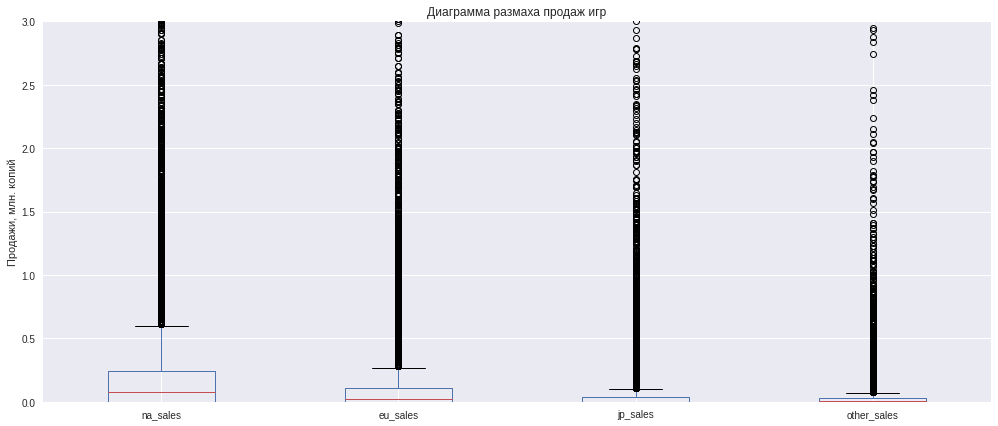

In [17]:
plt.style.use('seaborn')
plt.figure(figsize=(17, 7))
games.boxplot(column=['na_sales', 'eu_sales', 'jp_sales', 'other_sales'])
plt.ylim(0, 3)
plt.ylabel('Продажи, млн. копий')
plt.title('Диаграмма размаха продаж игр')
plt.show()

Видим, что диаграмма показывает немаленькое количество аномальных значений. В Северной Америке в норме количество проданных копий до 600 тыс., в остальных регионах в пределах 500 тыс. Однако, продажи некоторых игр доходят и до 40 млн. копий. На самом деле, такие значения вполне могут быть реальны, ведь разные игры разнятся по популярности! Поэтому с аномалиями делать мы ничего не будем, так как можем потерять ценные данные.

### Подсчет суммарных продаж

Для дальнейшего проведения исследования нам будет необходимы значения суммарных продаж копий игр по всем регионам. Произведем расчет и поместим это значение в новуюю колонку в датафрейме.

In [18]:
#расчитаем суммарные продажи по регионам и добавим значение в новую колонку
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
#проверяем
games.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,80.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1.0,-1.0,not defined,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,83.0,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,80.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1.0,-1.0,not defined,31.38


Колонка с общими продажами добавлена.

**Вывод по разделу:** В ходе предобработки мы:
- привели названия колонок к нижнему регистру;
- пропуски в колонках `name`, `genre` и `year_of_release` мы удалили, так как их 1,6% от общего объема данных
- пропуски в колонках `critic_score`, `user_score` и `rating` мы решили заменить на "заглушку", так как их более 50% и их удаление может привести к искажению результатов исследования
- пропуски в данных могли возникнуть по многим причинам: ошибки при загрузке данных, человеческий фактор; пропуски в колонках с оценками и рейтингом могли возникнуть в связи с непопулярностью некоторых игр, их малоизвестностью или совсем недавним релизом; также одной причиной пропусков может быть факт, что ESRB предназначен для северо-американских игр, а другие игры оцениваются по другой системе рейтинга: в Японии это CERO, а в Европе - PEGI;
- в колонке `rating` заменили значения 'К-А' заменили на 'Е', так как они обозначают одно и то же и аббревиатура 'К-А' устаревшая;
- в колонке `user_score` заменили значение "tbd" на "заглушку", поскольку аббревиатура означает, что оценка "не определена";
- заменили типы данных в колонке `year_of_release` на int и в колонке `user_score` на float;
- оценку в колонке `user_score` привели к 100-бальной системе исчисления, чтобы можно было сравнивать с колонкой `critic_score`;
- нашли неявный дубликат игры "Madden NFL 13", удалили одну из строк, так как она содержала нулевые значения продаж;
- аномалии в колонках с продажами мы оставили, потому что такие значения могут быть вполне реальными с учетом популярности некоторых игр;
- добавили колонку `total_sales` с суммарными продажами по регионам.

## Исследовательский анализ данных

### Выпуск игр по годам

Посмотрим, как выпускались игры по годам, динамику выпуска. Для этого построим график.

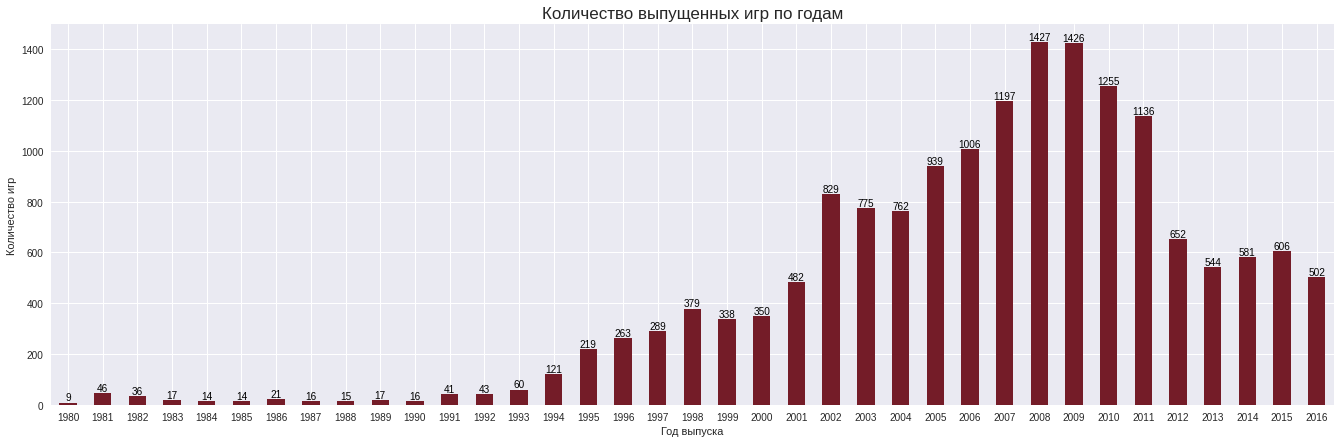

In [19]:
#создадим сводную таблицу с количеством выпущенных игр за каждый год
game_year_release = games.pivot_table(index='year_of_release', values='name', aggfunc='count')
#построим столбчатый график
plt.style.use('seaborn')
ax = game_year_release.plot(kind='bar', figsize=(23, 7), color='#741C28', rot=0, legend=False)

#добавим надписи значений над каждой платформой
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
    
plt.title('Количество выпущенных игр по годам', fontsize=17)
plt.xlabel('Год выпуска')
plt.ylabel('Количество игр')
plt.show()

С 1980 по 2000 годы индустрия игр развивалась в достаточно слабом темпе, хотя с 1994 года мы начинаем видеть подъем. Скорее всего в то время игры были дорогим удовольствием, и мало кто мог себе это позволить. Также в те годы было не так много компьютерных компаний, в связи с чем было ограниченное количество платформ и девайсов для выпуска игр и их реализации.

Ситуация улучшилась с 2000 года. Начинается "золотая эпоха" игровой индустрии. Появляется большое количество компьютерных компаний, производится больше девайсов, выходят самые популярные игры, разработчики стали все больше обращать внимание на дизайн игр и новые крутые фишки, что, соответственно, поднимало интерес к играм и возможность их приобрести. Продажи увеличивались.

Пик продажи игр пришелся на 2008-2009 год, несмотря на то, что эти годы ознаменовали начало мирового экономического кризиса. Перед началом кризиса, обычно, это нормальное явление, люди начинают много скупать. Но далее мы видим резкий спад в индустрии, что связано с последствиями кризиса и поиском компаниями решений, чтобы его пережить и не обанкротиться.

До 1995 года количество продаж слабо отражает реальную и современную динамику продаж игр, поэтому эти данные не будут нам так важны.

### Продажи по платформам

Посмотрим суммарные продажи по платформам за весь период наблюдений.

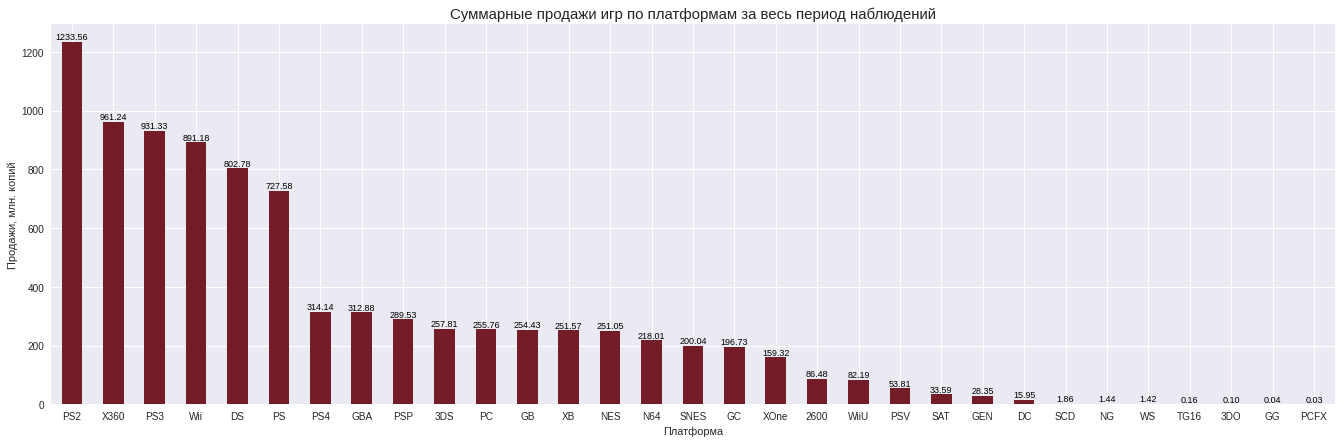

In [20]:
#построим график суммарных продаж по платформам за весь период наблюдений
ax = (games.groupby('platform')
      .agg({'total_sales': 'sum'})
      .sort_values(by='total_sales', ascending=False)
      .plot(kind='bar', figsize=(23, 7), color='#741C28', rot=0, legend=False)
)

#добавим надписи значений над каждой платформой
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('Суммарные продажи игр по платформам за весь период наблюдений', fontsize=15)
plt.xlabel('Платформа')
plt.ylabel('Продажи, млн. копий')
plt.show()

На графике явно выделяются 6 платформ-лидеров по продажам игр: PS2 - более 1 млрд копий; X360, PS3 - более 900 млн копий; Wii, DS - более 800 млн копий и PS - более 700 млн копий. 

Посмотрим распределение продаж игр у этих платформ по годам.

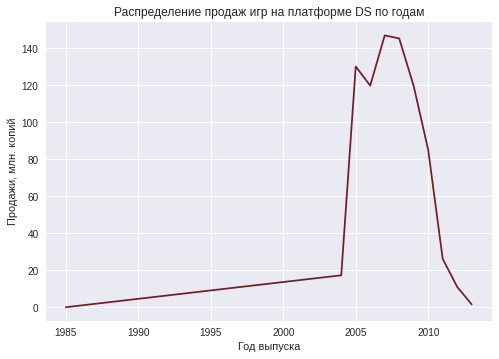

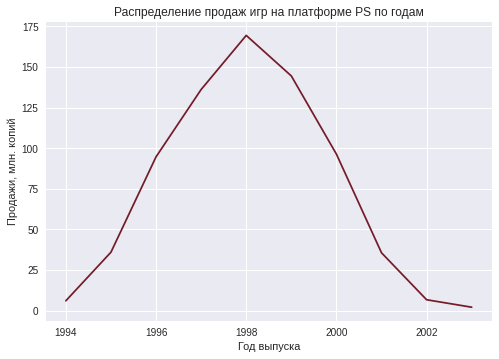

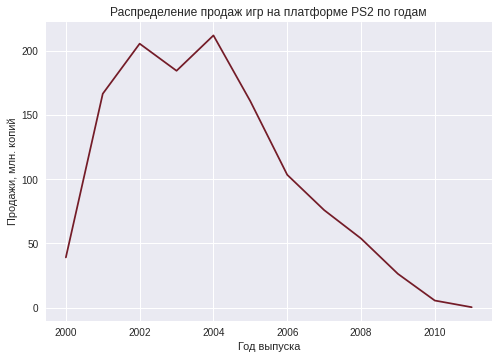

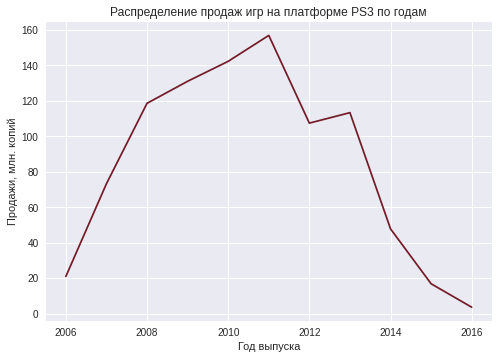

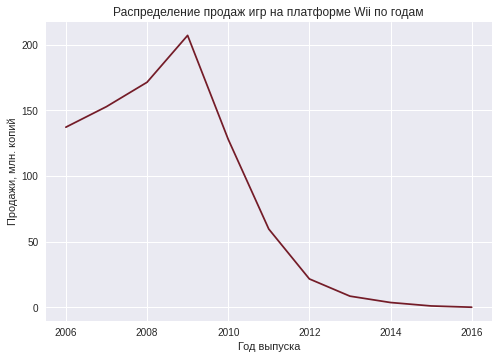

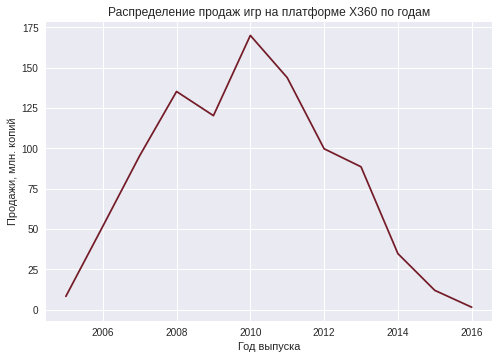

In [21]:
#сводная таблица с платформами-лидерами
top_platforms = (
    games.query('platform == "PS2" or platform == "X360" or platform == "PS3" or platform == "Wii" or platform == "DS" or platform == "PS"')
    .pivot_table(index='platform', values='total_sales', aggfunc='sum')
)

#построим распределения
for platform in top_platforms.index:
    (games
     .query('platform == @platform')
     .pivot_table(index='year_of_release', values='total_sales', aggfunc='sum')
     .plot(color='#741C28', legend=False)
    )
     
    plt.title(f'Распределение продаж игр на платформе {platform} по годам')
    plt.xlabel('Год выпуска')
    plt.ylabel('Продажи, млн. копий')
    plt.show()

Посмотрим какой средний срок жизни у платформ.

In [22]:
platform_lifetime = games.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
platform_lifetime['lifetime'] = platform_lifetime['max'] - platform_lifetime['min'] + 1 
print(f"Средняя жизнь игровой платформы составляет {platform_lifetime['lifetime'].median()} лет.")

Средняя жизнь игровой платформы составляет 7.0 лет.


Видим, что по платформам **DS**, **PS** и **PS2** продажи игр уже не ведутся. Можно сделать предположение, что эти платформы уже устарели.

По платформам **PS3**, **Wii** и **X360** к 2016 году продажи игр приблизились к нулевой отметке. Это может значить, что они тоже начинают устаревать и выпуск игр по этим платформам вряд ли будет планироваться в дальнейшем.

В основном, платформы остаются популярными для потребителя в течение, примерно, 4 лет. А вот период их жизни в среднем составляет около 7 лет. 

На примере платформы PlayStation можем отследить срок, когда появляются новые и исчезают старые платформы. С 1994 года начинают появляться игры на PS, к 2002 году продажи на этой платформе окончательно падают. В тоже время, в 2000 году выходит PS2, продажи на этой платформе растут до 2004 года и к 2006 году происходит резкое падение, потому что как раз в этот год стартуют продажи уже на новой PS3. Как видим, продажи на PS3 стремительно падают с 2013 года. Именно в этот год происходит релиз PS4. Таким образом, **характерным сроком появления новых и исчезновения старых платформ можно считать около 6 лет**.

Такие тенденции, как правило, могут быть связаны с трендами, конкуренцией и прогрессом, ведь чем старше консоль, тем хуже она отвечает техническим требованиям новых игр.

### Выбираем актуальный период

Для того, чтобы построить прогноз на 2017 год, нам нужно выбрать наиболее актуальный период для анализа данных. Мы будем рассматривать период с 2012 по 2016 годы. В 2012 году произошел спад продаж больше, чем вполовину по сравнению с пиком в 2009 году. Поэтому именно с этого года данные будут отражать реальную картину событий на рынке игровой индустрии в настоящее время.

In [23]:
#сохраним данные с 2012 по 2016 годы в новую переменную
games_new = games[games['year_of_release'] >= 2012].reset_index(drop=True)
#посмотрим сколько строк у нас осталось
print(games_new.shape)

(2885, 12)


Убрали все данные до 2012 года. В итоге у нас осталось 2886 строк для предстоящего анализа.

### Платформы, лидирующие по продажам

Посмотрим, какие платформы являются лидерами продаж с 2012 по 2016 годы.

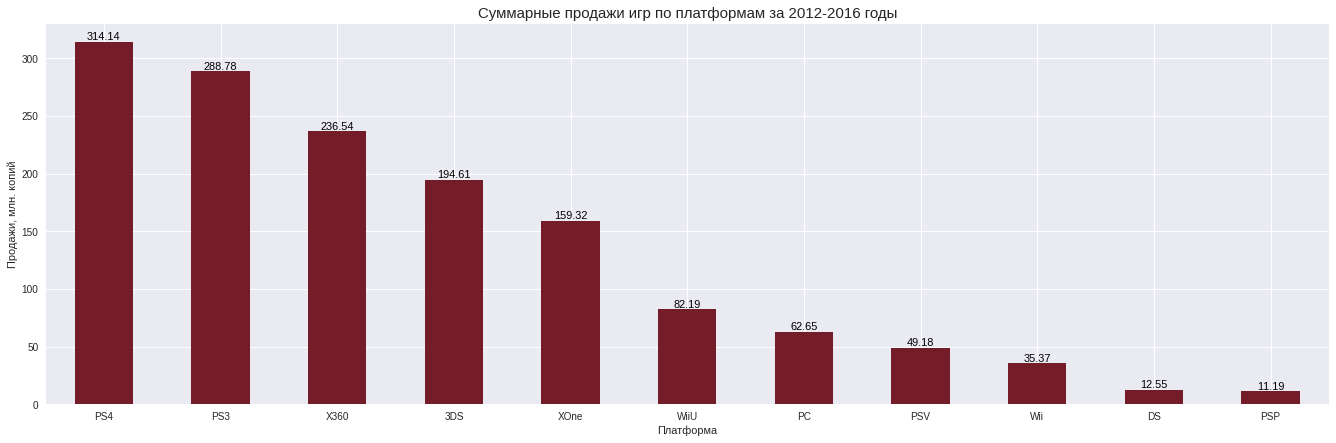

In [24]:
#построим график суммарных продаж по платформам с 2012 по 2016 годы
ax = (games_new.groupby('platform')
      .agg({'total_sales': 'sum'})
      .sort_values(by='total_sales', ascending=False)
      .plot(kind='bar', figsize=(23, 7), color='#741C28', rot=0, legend=False)
)

#добавим надписи значений над каждой платформой
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('Суммарные продажи игр по платформам за 2012-2016 годы', fontsize=15)
plt.xlabel('Платформа')
plt.ylabel('Продажи, млн. копий')
plt.show()

Относительно такого же графика за весь период наблюдений, картина за последние 5 лет отличается. В период с 2012 по 2016 годы явными лидерами продаж становятся следующие 3 платформы: PS4, PS3 и X360 (хотя PS3 и X360 были в лидерах и в предыдущем графике, до фильтрации). 

Теперь посмотрим на динамику продаж каждой платформы по годам.

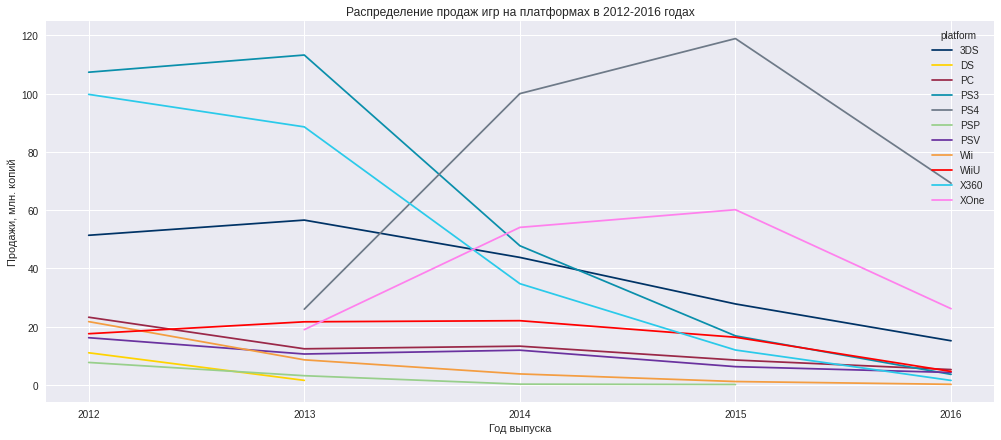

In [25]:
#построим график распределения продаж по платформам в период 2012-2016 г
(games_new
     .pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')
     .plot(figsize=(17,7), color=['#003366', '#ffd300', '#9a2848', '#0a8fab', '#6e7a88', '#98cf8b', '#6a329f', '#f49d41', '#ff0000', '#2acaea', '#ff80ed'])
    )
     
plt.title('Распределение продаж игр на платформах в 2012-2016 годах')
plt.xlabel('Год выпуска')
plt.ylabel('Продажи, млн. копий')
plt.xticks([2012, 2013, 2014, 2015, 2016])
plt.show()

Можно отметить, что продажи игр для платформы DS закончились в 2013 году, а для PSP - в 2015 году. 

Что также сразу бросается в глаза - это то, что продажи игр на всех остальных платформах к 2016 году снижаются. Но, как сказано в ТЗ, за 2016 год у нас не полные данные. Поэтому выберем **3 потенциально прибыльные платформы**, которые к 2016 году все еще **имеют наибольшее количество проданных копий**, а именно: **PS4** - несомненный лидер, **XOne** и **3DS**.

### Разброс суммарных глобальных продаж игр в разбивке по платформам c 2012 по 2016 годы

Посмотрим, как разбросаны глобальные продажи игр по платформам в 2012-2016 годах. Для этого построим диаграммы разброса.

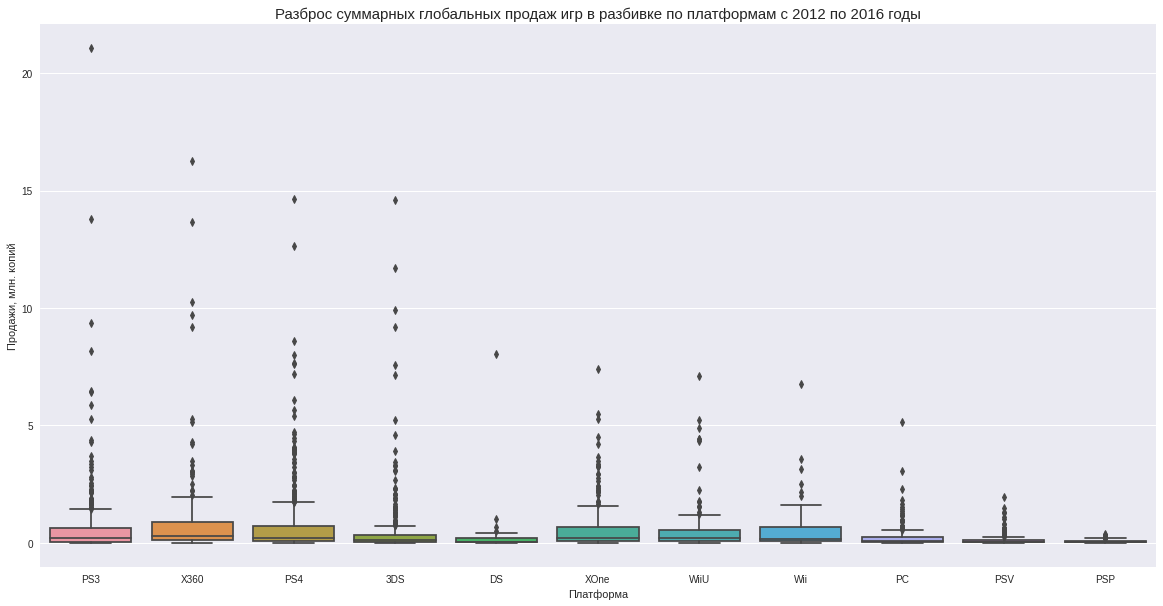

In [26]:
#строим диаграмму разброса продаж игр по платформам в 2012-2016 годах
plt.figure(figsize=(20, 10))
sns.boxplot(data=games_new, x='platform', y='total_sales')
plt.title('Разброс суммарных глобальных продаж игр в разбивке по платформам c 2012 по 2016 годы', fontsize=15)
plt.xlabel('Платформа')
plt.ylabel('Продажи, млн. копий')
plt.show()

Видим, что нормальные значения продаж по всем платформам укладываются в 2 млн копий. Есть некоторое количество выбросов по каждой платформе. Эти выбросы могут обозначать игры, которые оказались очень популярны среди игровой аудитории и продавались огромным количеством копий, принося владельцам платформ неплохую прибыль.

Посмотрим на картину поближе. Ограничим ось Y 3 млн копий.

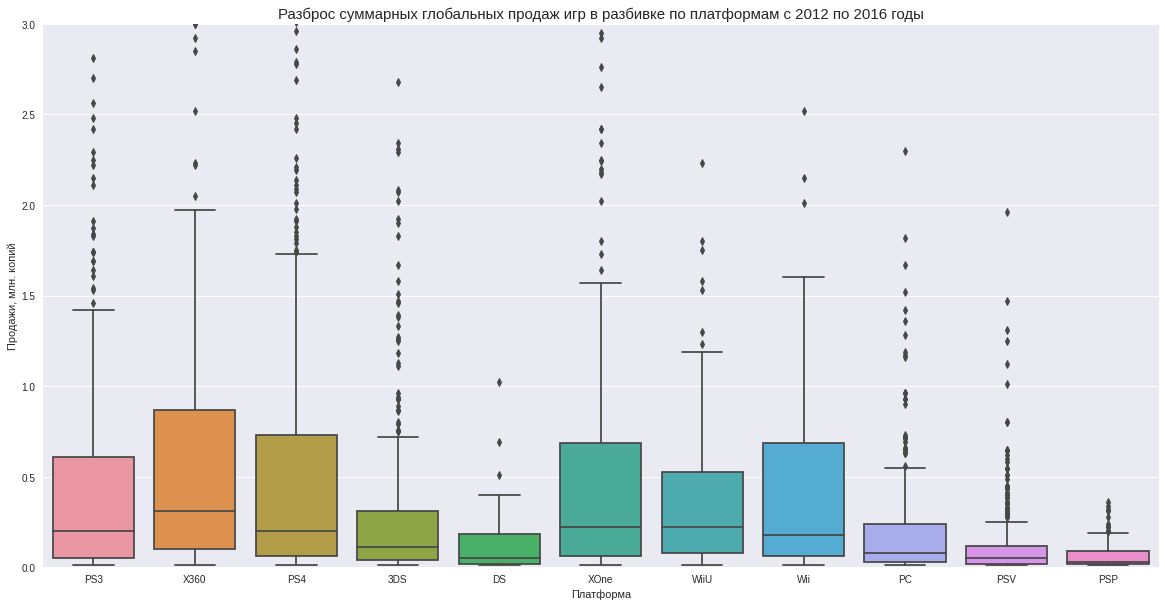

In [27]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=games_new, x='platform', y='total_sales')
plt.title('Разброс суммарных глобальных продаж игр в разбивке по платформам c 2012 по 2016 годы', fontsize=15)
plt.xlabel('Платформа')
plt.ylabel('Продажи, млн. копий')
plt.ylim(0, 3)
plt.show()

Смотря на разброс продаж копий картина немного меняется. Несомненно у каждой платформы есть положительные выбросы, которые принесли неплохой доход владельцам. Медианные значения продаж не очень сильно отличаются по платформам, и находятся в области 0,2-0,25 млн проданных копий. Исключение составляют платформы PSP, DS, PSV и PS - у этих платформ достаточно низкие медианные значения продаж.

Внимание на себя обращает платформа X360. Она явно лидирует по плотности продаж копий, а так же имеет наибольшее медианное значение в области 0,25 млн проданных копий. 

Также стоит считать перспективной платформу PS4. Она имеет очень плотный разброс продаж за пределами 3 квартиля, что говорит о большом количестве продаж отдельных игр и популярности платформы.

Стоит отметить, что платформа PSP уже изживает себя в выбранный нами период и является явным оутсайдером по продажам среди всех платформ. Сомнительно предполагать, что ситуация с этой платформой улучшится.

Анализируя картину динамики продаж игр на платформах по годам из предыдущего пункта и разброс суммарных глобальных продаж, можно смело выделить **одну лидирующую в последние годы платформу** - это **PS4**.

### Влияние оценок пользователей и критиков на продажи игр внутри платформы PS4

В прошлом пункте мы уже выбрали одну самую популярную, на наш взгляд, платформу - это PS4. С ней и будем работать.

Для того, чтобы понять, влияют ли оценки на продажи игр построим диаграмму рассеяния и посчитаем корреляцию между этими показателями.

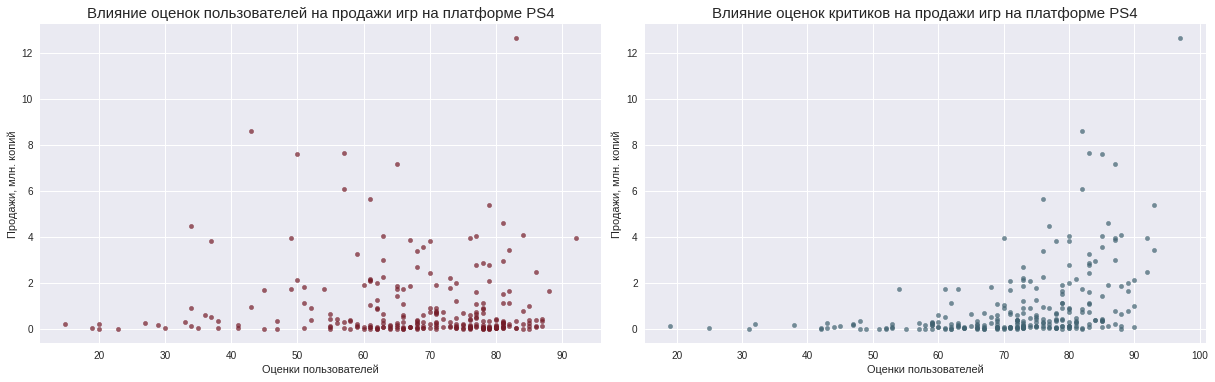

In [28]:
#строим график влияния оценок пользователей на продажи игр PS4
ax1 = plt.subplot(2, 2, 1)
ax = (games_new
      .query('platform == "PS4" & user_score != -1')
      .plot(kind='scatter', x='user_score', y='total_sales', figsize=(17, 10), grid=True, color= '#741C28', alpha=0.7, ax=ax1)
     )
plt.title('Влияние оценок пользователей на продажи игр на платформе PS4', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

#строим график влияния оценок критиков на продажи игр PS4
ax2 = plt.subplot(2, 2, 2)
ax = (games_new
      .query('platform == "PS4" & critic_score != -1')
      .plot(kind='scatter', x='critic_score', y='total_sales', figsize=(17, 10), grid=True, color= '#406270', alpha=0.7, ax=ax2)
     )
plt.title('Влияние оценок критиков на продажи игр на платформе PS4', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

plt.tight_layout()
plt.show()

Посчитаем корреляцию оценок пользователей и критиков по отношению к продажам.

In [29]:
ps4_games = games_new[games_new['platform'] == 'PS4']
print('Корреляция между оценками пользователей и продажами на платформе PS4 составляет -', ps4_games[ps4_games['user_score'] != -1]['user_score'].corr(ps4_games['total_sales']).round(3))
print('Корреляция между оценками критиков и продажами на платформе PS4 составляет -', ps4_games[ps4_games['critic_score'] != -1]['critic_score'].corr(ps4_games['total_sales']).round(3))

Корреляция между оценками пользователей и продажами на платформе PS4 составляет - -0.032
Корреляция между оценками критиков и продажами на платформе PS4 составляет - 0.407


Влияние оценок пользователей на продажи на платформе PS4 вообще не прослеживается как по графику, так и по достаточно низкому значению корреляции равному 0,032. Взаимосвязь оценок критиков и продаж игр на платформе PS4 слабая, но сильнее чем пользовательских оценок. В этом случае корреляция составила 0,407. 

Такая ситуация с оценками могла сложиться из-за того, что критики получают игру до ее релиза и могут оценить ее раньше всех. У критиков есть своя репутация среди геймеров, поэтому их оценки хоть и слабо, но влияют на продажи игр. Оценки же пользователей выставляются уже после релиза игр и больше связаны с "вкусовщиной", а также ожиданиями от игры и оправдались ли они. Можно предположить, что на продажи больше влияет PR-компания игр, обещания разработчиков и сформированный вокруг игр ажиотаж.

### Влияние оценок пользователей и критиков на продажи игр внутри платформ XOne, 3DS, X360 и PS3

Для сравнения также посмотрим как влияют оценки пользователей и критиков на продажи внутри четырех других популярных платформ XOne, 3DS, X360 и PS3.

#### XOne

Построим диаграмму рассеяния и посчитаем корреляцию между оценками и продажами по платформе XOne.

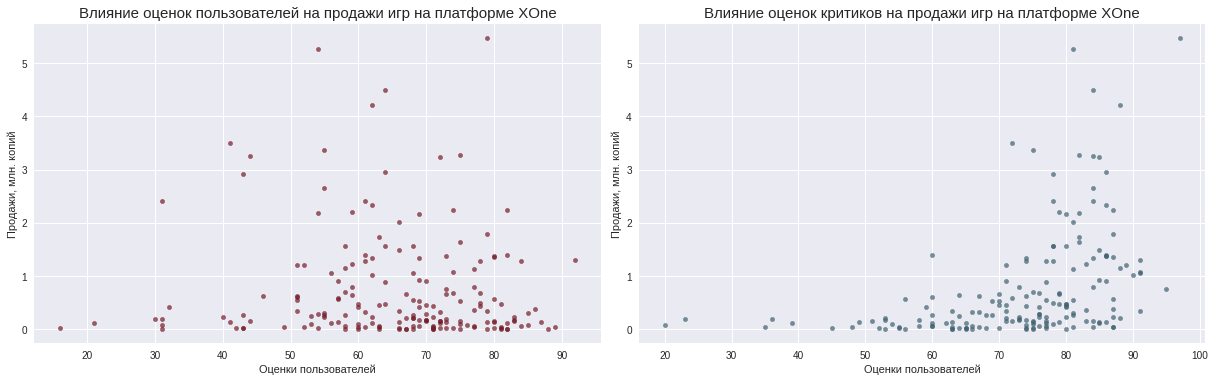

In [30]:
#строим график влияния оценок пользователей на продажи игр XOne
ax1 = plt.subplot(2, 2, 1)
ax = (games_new
      .query('platform == "XOne" & user_score != -1')
      .plot(kind='scatter', x='user_score', y='total_sales', figsize=(17, 10), grid=True, color= '#741C28', alpha=0.7, ax=ax1)
     )
plt.title('Влияние оценок пользователей на продажи игр на платформе XOne', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

#строим график влияния оценок критиков на продажи игр XOne
ax2 = plt.subplot(2, 2, 2)
ax = (games_new
      .query('platform == "XOne" & critic_score != -1')
      .plot(kind='scatter', x='critic_score', y='total_sales', figsize=(17, 10), grid=True, color= '#406270', alpha=0.7, ax=ax2)
     )
plt.title('Влияние оценок критиков на продажи игр на платформе XOne', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

plt.tight_layout()
plt.show()

Посчитаем корреляцию оценок пользователей и критиков по отношению к продажам.

In [31]:
xone_games = games_new[games_new['platform'] == "XOne"]
print('Корреляция между оценками пользователей и продажами на платформе XOne составляет -', xone_games[xone_games['user_score'] != -1]['user_score'].corr(xone_games['total_sales']).round(3))
print('Корреляция между оценками критиков и продажами на платформе XOne составляет -', xone_games[xone_games['critic_score'] != -1]['critic_score'].corr(xone_games['total_sales']).round(3))

Корреляция между оценками пользователей и продажами на платформе XOne составляет - -0.069
Корреляция между оценками критиков и продажами на платформе XOne составляет - 0.417


По платформе XOne видим почти такую же картину.

#### 3DS

Построим диаграмму рассеяния и посчитаем корреляцию между оценками и продажами по платформе 3DS.

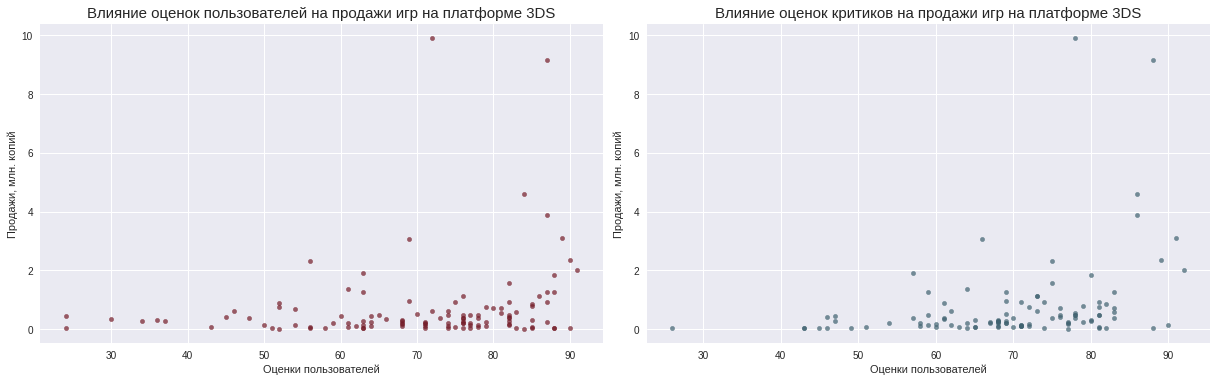

In [32]:
#строим график влияния оценок пользователей на продажи игр 3DS
ax1 = plt.subplot(2, 2, 1)
ax = (games_new
      .query('platform == "3DS" & user_score != -1')
      .plot(kind='scatter', x='user_score', y='total_sales', figsize=(17, 10), grid=True, color= '#741C28', alpha=0.7, ax=ax1)
     )
plt.title('Влияние оценок пользователей на продажи игр на платформе 3DS', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

#строим график влияния оценок критиков на продажи игр 3DS
ax2 = plt.subplot(2, 2, 2)
ax = (games_new
      .query('platform == "3DS" & critic_score != -1')
      .plot(kind='scatter', x='critic_score', y='total_sales', figsize=(17, 10), grid=True, color= '#406270', alpha=0.7, ax=ax2)
     )
plt.title('Влияние оценок критиков на продажи игр на платформе 3DS', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

plt.tight_layout()
plt.show()

Посчитаем корреляцию оценок пользователей и критиков по отношению к продажам.

In [33]:
games_3ds = games_new[games_new['platform'] == "3DS"]
print('Корреляция между оценками пользователей и продажами на платформе 3DS составляет -', games_3ds[games_3ds['user_score'] != -1]['user_score'].corr(games_3ds['total_sales']).round(3))
print('Корреляция между оценками критиков и продажами на платформе 3DS составляет -', games_3ds[games_3ds['critic_score'] != -1]['critic_score'].corr(games_3ds['total_sales']).round(3))

Корреляция между оценками пользователей и продажами на платформе 3DS составляет - 0.198
Корреляция между оценками критиков и продажами на платформе 3DS составляет - 0.321


По 3DS ситуация аналогична.

#### X360

Построим диаграмму рассеяния и посчитаем корреляцию между оценками и продажами по платформе X360.

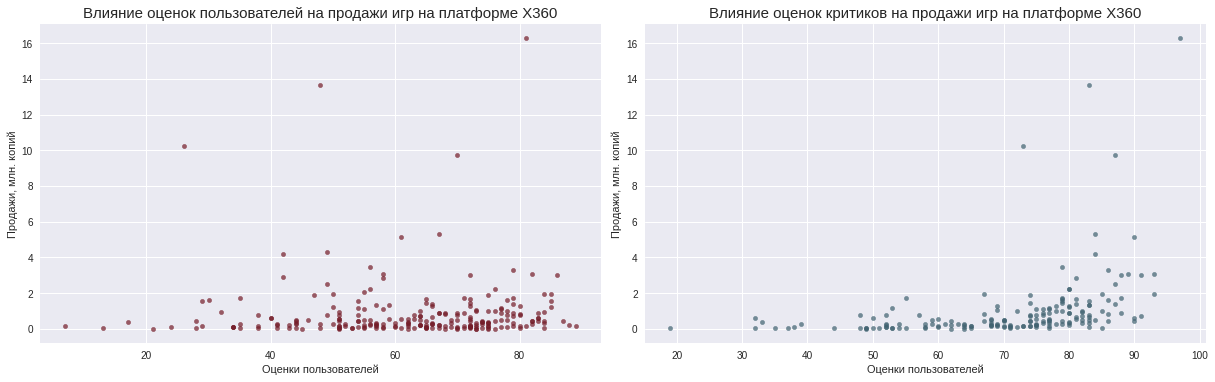

In [34]:
#строим график влияния оценок пользователей на продажи игр X360
ax1 = plt.subplot(2, 2, 1)
ax = (games_new
      .query('platform == "X360" & user_score != -1')
      .plot(kind='scatter', x='user_score', y='total_sales', figsize=(17, 10), grid=True, color= '#741C28', alpha=0.7, ax=ax1)
     )
plt.title('Влияние оценок пользователей на продажи игр на платформе X360', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

#строим график влияния оценок критиков на продажи игр X360
ax2 = plt.subplot(2, 2, 2)
ax = (games_new
      .query('platform == "X360" & critic_score != -1')
      .plot(kind='scatter', x='critic_score', y='total_sales', figsize=(17, 10), grid=True, color= '#406270', alpha=0.7, ax=ax2)
     )
plt.title('Влияние оценок критиков на продажи игр на платформе X360', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

plt.tight_layout()
plt.show()

Посчитаем корреляцию оценок пользователей и критиков по отношению к продажам.

In [35]:
games_x360 = games_new[games_new['platform'] == "X360"]
print('Корреляция между оценками пользователей и продажами на платформе X360 составляет -', games_x360[games_x360['user_score'] != -1]['user_score'].corr(games_x360['total_sales']).round(3))
print('Корреляция между оценками критиков и продажами на платформе X360 составляет -', games_x360[games_x360['critic_score'] != -1]['critic_score'].corr(games_x360['total_sales']).round(3))

Корреляция между оценками пользователей и продажами на платформе X360 составляет - 0.006
Корреляция между оценками критиков и продажами на платформе X360 составляет - 0.361


И по платформе X360 картина совпадает.

#### PS3

А что же происходит на платформе PS3? Разбираемся.

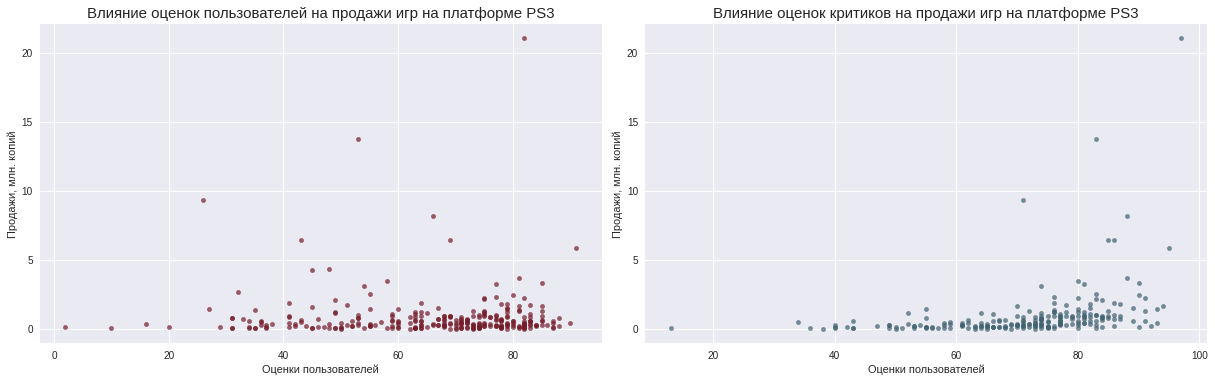

In [36]:
#строим график влияния оценок пользователей на продажи игр PS3
ax1 = plt.subplot(2, 2, 1)
ax = (games_new
      .query('platform == "PS3" & user_score != -1')
      .plot(kind='scatter', x='user_score', y='total_sales', figsize=(17, 10), grid=True, color= '#741C28', alpha=0.7, ax=ax1)
     )
plt.title('Влияние оценок пользователей на продажи игр на платформе PS3', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

#строим график влияния оценок критиков на продажи игр PS3
ax2 = plt.subplot(2, 2, 2)
ax = (games_new
      .query('platform == "PS3" & critic_score != -1')
      .plot(kind='scatter', x='critic_score', y='total_sales', figsize=(17, 10), grid=True, color= '#406270', alpha=0.7, ax=ax2)
     )
plt.title('Влияние оценок критиков на продажи игр на платформе PS3', fontsize=15)
plt.ylabel('Продажи, млн. копий')
plt.xlabel('Оценки пользователей')

plt.tight_layout()
plt.show()

А что же корреляция?

In [37]:
ps3_games = games_new[games_new['platform'] == "PS3"]
print('Корреляция между оценками пользователей и продажами на платформе PS3 составляет -', ps3_games[ps3_games['user_score'] != -1]['user_score'].corr(ps3_games['total_sales']).round(3))
print('Корреляция между оценками критиков и продажами на платформе PS3 составляет -', ps3_games[ps3_games['critic_score'] != -1]['critic_score'].corr(ps3_games['total_sales']).round(3))

Корреляция между оценками пользователей и продажами на платформе PS3 составляет - -0.006
Корреляция между оценками критиков и продажами на платформе PS3 составляет - 0.334


И у PS3 все аналогично!

Как видим, у среди всех выделенных нами популярных платформ - PS4, XOne, 3DS, X360 и PS3- оценки пользователей вообще не влияют на продажи, о чем и говорят низкие коэффициенты корреляции почти равные 0. Оценки критиков имеют большее влияние на продажи игр, но все же достаточно слабые (коэффициенты корреляции в диапазоне 0,3-0,4).
Ранее уже высказали предположение, что такая картина может быть связана с безусловной репутацией критиков среди геймеров и любителей игр, но, скорее всего, PR-кампания, создаваемый ажиотаж и обещания разработчиков имеют бОльшее влияние на продажи.

### Самые популярные жанры игр

Интересно, как распределялись продажи по жанрам игр в период с 2012 по 2016 годы. Какие жанры оказались самыми поулярными у пользователей?

Построим столбчатую диаграмму.

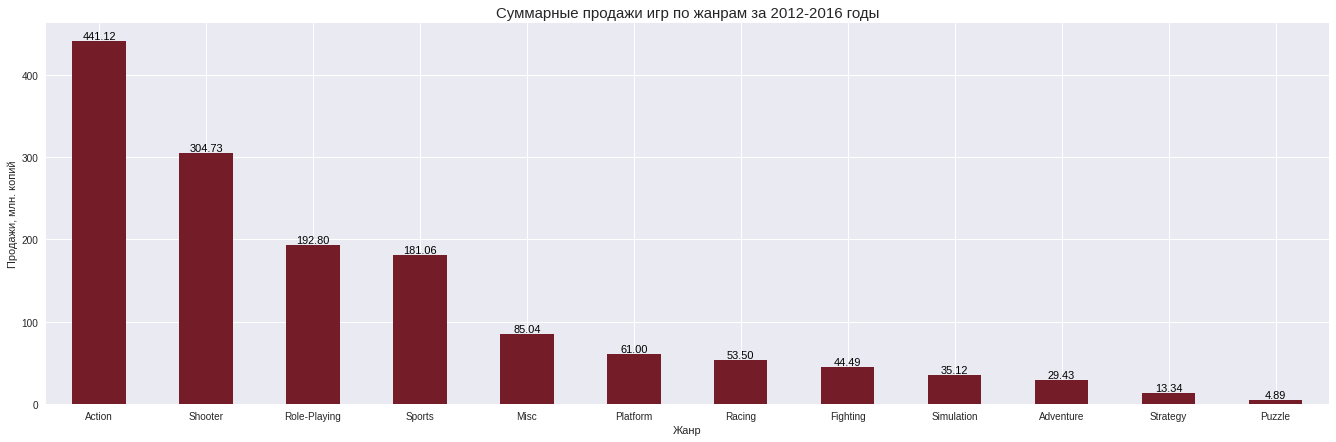

In [38]:
#построим график суммарных продаж по жанрам с 2012 по 2016 годы
ax = (games_new.groupby('genre')
      .agg({'total_sales': 'sum'})
      .sort_values(by='total_sales', ascending=False)
      .plot(kind='bar', figsize=(23, 7), color='#741C28', rot=0, legend=False)
)

#добавим надписи значений над каждым жанром
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('Суммарные продажи игр по жанрам за 2012-2016 годы', fontsize=15)
plt.xlabel('Жанр')
plt.ylabel('Продажи, млн. копий')
plt.show()

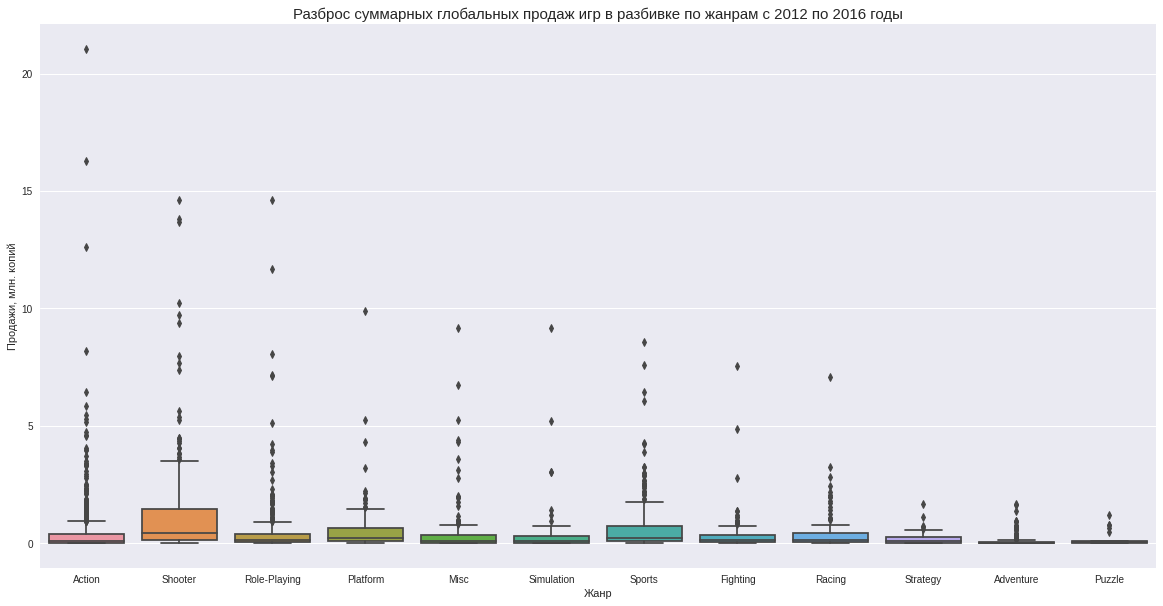

In [39]:
#строим диаграмму разброса продаж игр по платформам в 2012-2016 годах
plt.figure(figsize=(20, 10))
sns.boxplot(data=games_new, x='genre', y='total_sales')
plt.title('Разброс суммарных глобальных продаж игр в разбивке по жанрам c 2012 по 2016 годы', fontsize=15)
plt.xlabel('Жанр')
plt.ylabel('Продажи, млн. копий')
#plt.ylim(0, 5)
plt.show()

Среди самых популярных жанров ярко выделяются Action, Shooter, Role-Playing и Sports. Оутсайдерами являются Puzzle, Strategy и Adventure - видимо, такие игры менее всего интересны аудитории.

При этом медианные продажи выше всего у жанра Shooter, он кажется более стабильным, по сравнению с остальными топовыми жанрами. Sports хоть и находится на 4 месте по количеству проданных копий, имеет второе по величине медианное значение продаж. Жанры Action и Role-Playing имеют примерно одинаковую и интересную картину распределения продаж. Медианные значения продаж не самые высокие, но имеется большое количество положительных выбросов, что говорит о том, что в этих жанрах выходило некоторое количество очень популярных и ажиотажных игр с огромным количеством проданных копий. В жанре Action были игры, проданные тиражом около 17 и 22 млн. копий - а это самые крупные продажи!

**Вывод по разделу:**
- Золотая эпоха игровой индустрии началась с 2000 года, достигла своего пика в 2008-2009 годах и к 2016 году снизились более, чем в 2 раза. Резкий спад продаж игр после 2009 года можно сопоставить с мировым экономическим кризисом, начавшимся в 2008 году.
- За весь период наблюдений явно выделяются **6 платформ-лидеров** по продажам игр: **PS2** - более 1 млрд копий; **X360**, **PS3** - более 900 млн копий; **Wii**, **DS** - более 800 млн копий и **PS** - более 700 млн копий.
- Платформы остаются популярными для потребителя в течение, примерно, 4 лет. А вот период их жизни в среднем составляет около 10 лет.
- Характерным сроком появления новых и исчезновения старых платформ можно считать около 6 лет. Такие тенденции, как правило, могут быть связаны с трендами, конкуренцией и прогрессом, ведь чем старше консоль, тем хуже она отвечает техническим требованиям новых игр.
- **Актуальный период** для анализа был выбран период **с 2012 по 2016 годы**. В 2012 году произошел спад продаж больше, чем вполовину по сравнению с пиком в 2009 году, и установился на одном уровне. Поэтому именно этот период отражает реальную картину событий на рынке игровой индустрии в настоящее время.
- **В период с 2012 по 2016 годы явными лидерами продаж становятся следующие 3 платформы**: **PS4, PS3 и X360**. А **3 потенциально прибыльные платформы**, которые к концу наблюдаемого периода все еще имеют наибольшее количество проданных копий -  **PS4** - несомненный лидер, **XOne** и **3DS**.
- Медианные значения продаж не очень сильно отличаются по платформам в 2012-2016 годах, и находятся в области 0,2-0,25 млн проданных копий. Исключение составляют платформы PSP, DS, PSV и PS - у этих платформ достаточно низкие медианные значения продаж. Платформа X360 явно лидирует по плотности продаж копий, а так же имеет наибольшее медианное значение в области 0,25 млн проданных копий. Платформу PS4 имеет очень плотный разброс продаж за пределами 3 квартиля, что говорит о большом количестве продаж отдельных игр и популярности платформы. А вот платформа PSP уже изживает себя в выбранный нами период и является явным оутсайдером по продажам среди всех платформ.
- Среди всех самых популярных платформ - PS4, XOne, 3DS, X360 и PS3 - **оценки пользователей вообще не влияют на продажи**, о чем и говорят низкие коэффициенты корреляции почти равные 0. **Оценки критиков** имеют большее влияние на продажи игр, но все же **достаточно слабое** (коэффициенты корреляции в диапазоне 0,3-0,4). Такая картина может быть связана с безусловной репутацией критиков среди геймеров и любителей игр, но, скорее всего, PR-кампания, создаваемый ажиотаж и обещания разработчиков имеют бОльшее влияние на продажи.
- Среди **самых популярных жанров** ярко выделяются **Action, Shooter, Role-Playing и Sports**. **Оутсайдерами** являются **Puzzle, Strategy и Adventure** - видимо, такие игры менее всего интересны аудитории. При этом медианные продажи выше всего у жанра Shooter, он кажется более стабильным, по сравнению с остальными топовыми жанрами. Sports хоть и находится на 4 месте по количеству проданных копий, имеет второе по величине медианное значение продаж. Жанры Action и Role-Playing имеют примерно одинаковую и интересную картину распределения продаж. Медианные значения продаж не самые высокие, но имеется большое количество положительных выбросов, что говорит о том, что в этих жанрах выходило некоторое количество очень популярных и ажиотажных игр с огромным количеством проданных копий. В жанре Action были игры, проданные тиражом около 17 и 22 млн. копий - а это самые крупные продажи!

## Портрет пользователя каждого региона

Какие же предпочтения в играх у пользователей разных регионов. Для ответа на этот вопрос составим портреты пользователей по регионам. В наших данных регионов представлено 3: NA - Северная Америка, EU - Европа и JP - Япония.

Для составления портрета выявим топ-5 самых популярных в регионе платформ, топ-5 самых популярных жанров и разберемся влияет ли рейтинг ESRB на продажи в регионах.

### Топ-5 самых популярных платформ по регионам

Сначала посмотрим топ-5 платформ по количеству продаж в Северной Америке, Европе и Японии. А также выведем их в долях продаж.

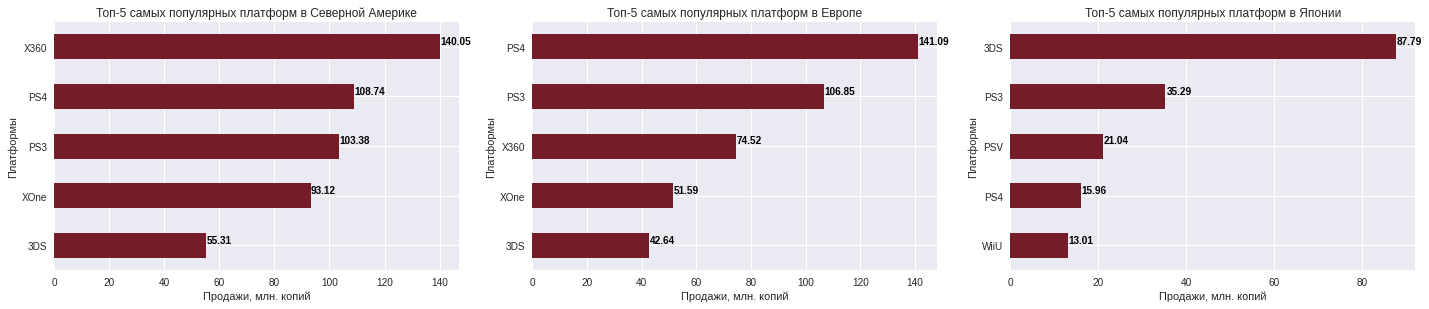

In [40]:
#строим графики с топ-5 самых популярных платформ по регионам
plt.style.use('seaborn')
ax1 = plt.subplot(2, 3, 1)
ax = (games_new.groupby('platform')
      .agg({'na_sales': 'sum'})
      .sort_values(by='na_sales', ascending=False)
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax1)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных платформ в Северной Америке')
plt.ylabel('Платформы')
plt.xlabel('Продажи, млн. копий')

ax2 = plt.subplot(2, 3, 2)
ax = (games_new.groupby('platform')
      .agg({'eu_sales': 'sum'})
      .sort_values(by='eu_sales', ascending=False)
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax2)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных платформ в Европе')
plt.ylabel('Платформы')
plt.xlabel('Продажи, млн. копий')

ax3 = plt.subplot(2, 3, 3)
ax = (games_new.groupby('platform')
      .agg({'jp_sales': 'sum'})
      .sort_values(by='jp_sales', ascending=False)
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax3)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных платформ в Японии')
plt.ylabel('Платформы')
plt.xlabel('Продажи, млн. копий')

plt.tight_layout()
plt.show()

Теперь посмотрим то же самое, но в долях продаж.

In [41]:
#считаем доли продаж по платформам в Северной Америке
na_share = games_new.pivot_table(index='platform', values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False)
na_share['share'] = na_share['na_sales'] / na_share['na_sales'].sum() * 100

#считаем доли продаж по платформам в Европе
eu_share = games_new.pivot_table(index='platform', values='eu_sales', aggfunc='sum').sort_values(by='eu_sales', ascending=False)
eu_share['share'] = eu_share['eu_sales'] / eu_share['eu_sales'].sum() * 100

#считаем доли продаж по платформам в Японии
jp_share = games_new.pivot_table(index='platform', values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False)
jp_share['share'] = jp_share['jp_sales'] / jp_share['jp_sales'].sum() * 100

Покажем на графиках топ-5 самых популярных платформ в долях продаж.

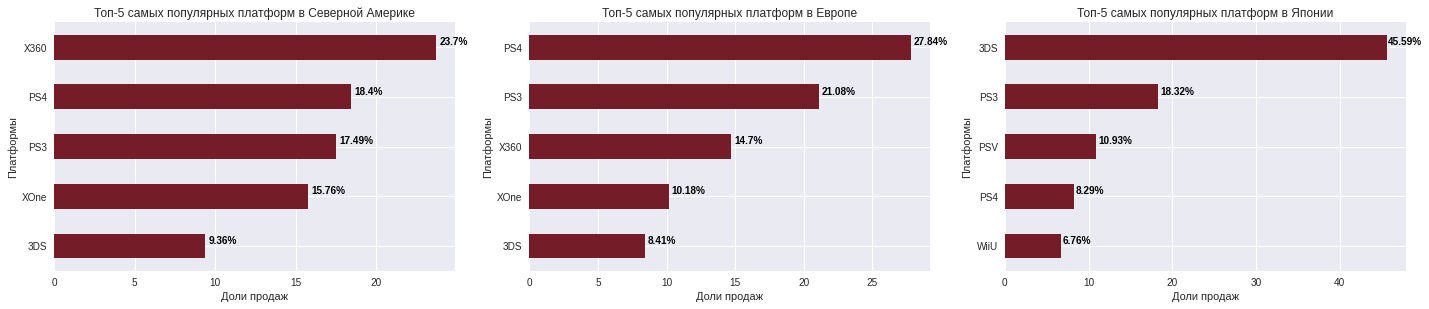

In [42]:
#строим графики топ-5 платформ в долях продаж
plt.style.use('seaborn')
ax1 = plt.subplot(2, 3, 1)
ax = (na_share['share']
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax1)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных платформ в Северной Америке')
plt.ylabel('Платформы')
plt.xlabel('Доли продаж')

ax2 = plt.subplot(2, 3, 2)
ax = (eu_share['share']
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax2)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных платформ в Европе')
plt.ylabel('Платформы')
plt.xlabel('Доли продаж')

ax3 = plt.subplot(2, 3, 3)
ax = (jp_share['share']
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax3)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных платформ в Японии')
plt.ylabel('Платформы')
plt.xlabel('Доли продаж')

plt.tight_layout()
plt.show()

Самые популярные платформы по регионам разнятся.

В Северной Америке самой популярной платформой является американская X360 c 23,7% от общих продаж. Ниже идут PS4, PS3 и XOne - доли продаж составляют 18,4%, 17,5% и 15,8% соответственно. Завершает топ-5 для Северной Америки платформа 3DS с 9,36% от общей суммы продаж.

В Европе список популярных платформ не отличается от северо-американского, но тут в лидеры выходят PS4 и PS3 - 27,84% и 21,08% соответственно. лидирующий в Северной Америке X360 в Европе занимает 3 место с долей продаж 14,7%. 4 и 5 строчки занимают XOne и 3DS - 10,18% и 8,41% соответственно. Такое сходство может быть обоснованно большим влиянием американских трендов на европейских пользователей.

Очень интересная картина сложилась в Японии! В топ-5 самых популярных платформ в Японии вошли только приставки от японских игровых компаний, что не удивительно, ведь японцы - передовики в создании игр. В лидерах в Японии яаляется платформа 3DS. На нее приходится целых 45,6% всех продаж. На 2 месте PS3 - 18,32% продаж. Менее популярными оказались PSV, PS4 и WiiU - 10,93%, 8,29% и 6,76% продаж соответственно.

### Топ-5 самых популярных жанров по регионам

Посмотрим как разнятся жанры игр в разных регионах.

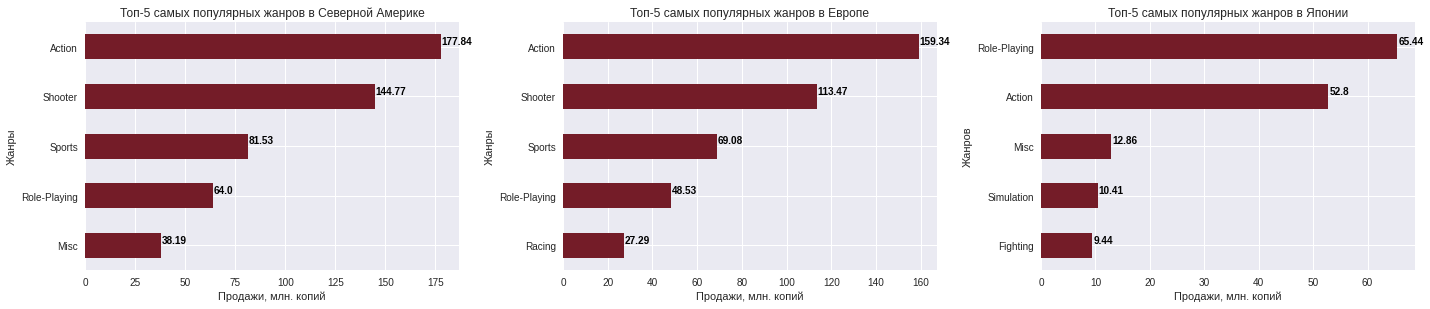

In [43]:
#строим графики с топ-5 самых популярных жанров по регионам
plt.style.use('seaborn')
ax1 = plt.subplot(2, 3, 1)
ax = (games_new.groupby('genre')
      .agg({'na_sales': 'sum'})
      .sort_values(by='na_sales', ascending=False)
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax1)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных жанров в Северной Америке')
plt.ylabel('Жанры')
plt.xlabel('Продажи, млн. копий')

ax2 = plt.subplot(2, 3, 2)
ax = (games_new.groupby('genre')
      .agg({'eu_sales': 'sum'})
      .sort_values(by='eu_sales', ascending=False)
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax2)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных жанров в Европе')
plt.ylabel('Жанры')
plt.xlabel('Продажи, млн. копий')

ax3 = plt.subplot(2, 3, 3)
ax = (games_new.groupby('genre')
      .agg({'jp_sales': 'sum'})
      .sort_values(by='jp_sales', ascending=False)
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax3)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных жанров в Японии')
plt.ylabel('Жанров')
plt.xlabel('Продажи, млн. копий')

plt.tight_layout()
plt.show()

Переведем все эти значения в доли продаж.

In [44]:
#считаем доли продаж по жанрам в Северной Америке
na_genre_share = games_new.pivot_table(index='genre', values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False)
na_genre_share['share'] = na_genre_share['na_sales'] / na_genre_share['na_sales'].sum() * 100

#считаем доли продаж по жанрам в Европе
eu_genre_share = games_new.pivot_table(index='genre', values='eu_sales', aggfunc='sum').sort_values(by='eu_sales', ascending=False)
eu_genre_share['share'] = eu_genre_share['eu_sales'] / eu_genre_share['eu_sales'].sum() * 100

#считаем доли продаж по жанрам в Японии
jp_genre_share = games_new.pivot_table(index='genre', values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False)
jp_genre_share['share'] = jp_genre_share['jp_sales'] / jp_genre_share['jp_sales'].sum() * 100

Изобразим на графиках топ-5 самых популярных жанров по регионам в долях продаж.

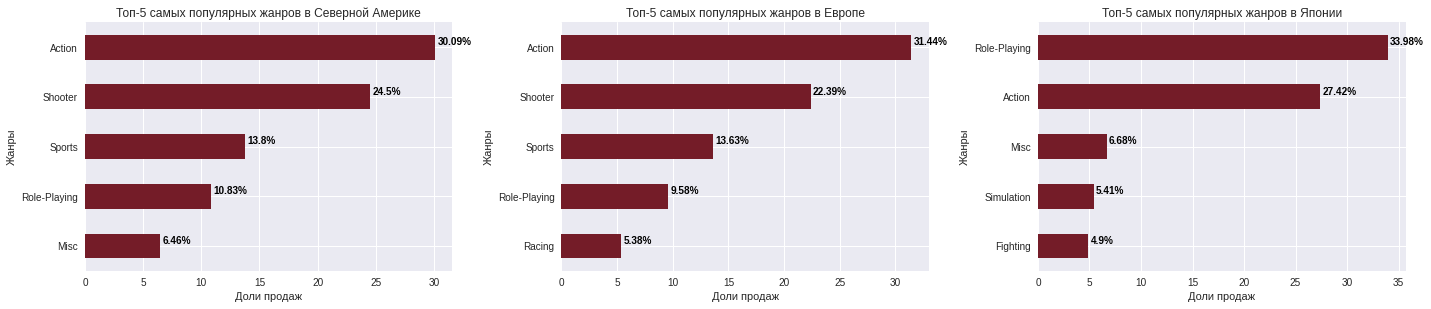

In [45]:
#строим графики топ-5 жанров в долях продаж
plt.style.use('seaborn')
ax1 = plt.subplot(2, 3, 1)
ax = (na_genre_share['share']
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax1)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных жанров в Северной Америке')
plt.ylabel('Жанры')
plt.xlabel('Доли продаж')

ax2 = plt.subplot(2, 3, 2)
ax = (eu_genre_share['share']
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax2)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных жанров в Европе')
plt.ylabel('Жанры')
plt.xlabel('Доли продаж')

ax3 = plt.subplot(2, 3, 3)
ax = (jp_genre_share['share']
      .head(5)
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax3)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Топ-5 самых популярных жанров в Японии')
plt.ylabel('Жанры')
plt.xlabel('Доли продаж')

plt.tight_layout()
plt.show()

Касаемо жанров, происходит похожая картина, что и с платформами.

В Северной Америке самыми популярными являются жанры Action и Shooter, на них приходится 30% и 24,5% всех продаж. Ниже идут спортивные и ролевые игры, а также игры смешанного жанра - 13,8%, 10,9% и 6,46% соответственно.

В Европе в топ-5 жанров входят те же жанры, что и в Северной Америке, причем в практически таком же процентном соотношении, за исключением последнего. На 5 месте в Европе жанр Racing - его доля от всех продаж составляет 5,38%.

По Японии картина отличается очень сильно. Преобладающую долю занимают 2 жанра - ролевые и экшн. На их долю приходится 33,9% и 27,42% соответственно. Дальше идут игры в жанрах Misc, Simulation и Fighting с долей от общих продаж 6,68%, 5,41% и 4,9% соответственно.

Такая динамика по регионам может быть обоснована тем, что в Европе и Америке очень похожа ментальность, культура и тренды. Отличие топовых жанров в Японии объясняется тем, что японские производители игр больше адаптируют их под вкусы и интересы японского населения (например, аниме), что может быть менее популярно в других регионах. 

### Влияние рейтинга ESRB на продажи в отдельных регионах

Посмотрим какую долю от всех продаж составляют игры по рейтингу ESRB в разных регионах.

In [46]:
#считаем доли продаж по рейтингу ESRB в Северной Америке
na_rating_share = games_new.pivot_table(index='rating', values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False)
na_rating_share['share'] = na_rating_share['na_sales'] / na_rating_share['na_sales'].sum() * 100

#считаем доли продаж по рейтингу ESRB в Европе
eu_rating_share = games_new.pivot_table(index='rating', values='eu_sales', aggfunc='sum').sort_values(by='eu_sales', ascending=False)
eu_rating_share['share'] = eu_rating_share['eu_sales'] / eu_rating_share['eu_sales'].sum() * 100

#считаем доли продаж по рейтингу ESRB в Японии
jp_rating_share = games_new.pivot_table(index='rating', values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False)
jp_rating_share['share'] = jp_rating_share['jp_sales'] / jp_rating_share['jp_sales'].sum() * 100

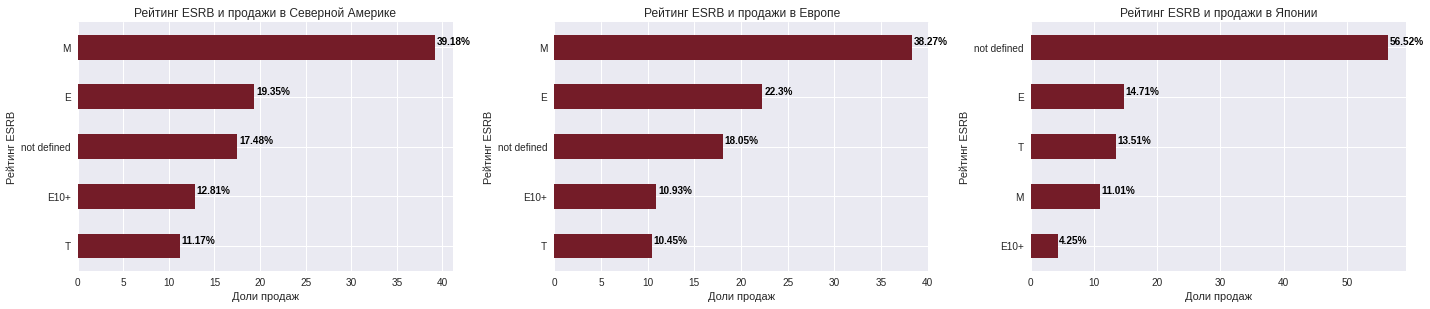

In [47]:
#строим графики продаж по рейтингу ESRB в долях 
plt.style.use('seaborn')
ax1 = plt.subplot(2, 3, 1)
ax = (na_rating_share['share']
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax1)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Рейтинг ESRB и продажи в Северной Америке')
plt.ylabel('Рейтинг ESRB')
plt.xlabel('Доли продаж')

ax2 = plt.subplot(2, 3, 2)
ax = (eu_rating_share['share']
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax2)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Рейтинг ESRB и продажи в Европе')
plt.ylabel('Рейтинг ESRB')
plt.xlabel('Доли продаж')

ax3 = plt.subplot(2, 3, 3)
ax = (jp_rating_share['share']
      .plot(kind='barh', figsize=(20, 8), legend=False, color='#741C28', ax=ax3)
     )
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             f'{str(round((i.get_width()), 2))}%',
             fontsize=10, fontweight='bold',
             color='black')
ax.invert_yaxis()
plt.title('Рейтинг ESRB и продажи в Японии')
plt.ylabel('Рейтинг ESRB')
plt.xlabel('Доли продаж')

plt.tight_layout()
plt.show()

Во всех регионах представлены одни и те же типы рейтинга ESRB. По гистограммам можем сказать, что в Северной Америке и Европе рейтинг почти не влияет на продажу игр, но вот в Японии совсем другая ситуация.

В Северной Америке и Европе лидируют игры с рейтингом "М" (для взрослых) - доли от продаж 39,18% (Северная Америка) и 38,27% (Европа). Дальше идут игры с рейтингом "Е" (для всех) - 19,35% (Северная Америка) и 22,3% (Европа), игры с неопределенным рейтингом - 17,48% (Северная Америка) и 18,05% (Европа), рейтинг "Е10+" (для всех старше 10 лет) - 12,81% (Северная Америка) и 10,93% (Европа), и, наконец, с рейтингом "Т" (для подростков) - 11,17% (Северная Америка) и 10,45% (Европа).

В Японии ситуация меняется. Тут явно лидируют игры с с неопределенным рейтингом - 56,52%, далее идут игры с рейтингом "Е" (для всех) - 14,71% от всех продаж, потом с рейтингом "Т" (для подростков) - 13,51%, с рейтингом "М" (для взрослых) - 11,01%, и завершают топ игры с рейтингом "Е10+" (для всех старше 10 лет) - 4,25%.

В общем, в Северной Америке и Европе картина почти идентичная, в отличие от Японии. Данную ситуацию можно объяснить тем, что в Японии есть своя система рейтинга игр CERO, ее правила распространяются только на японский рынок, так как в Японии запрещены игры со сценами жестокости и насилия. Некоторые производители зарубежных игр даже удаляют или переделывают некоторые сцены и обложки для того, чтобы быть допущенными к продажам в Японии. Именно в связи с такими строгими правилами в Японии более популярны игры с неопределенным рейтингом (скорее всего эти игры получают рейтинг по местной системе CERO), а также произведенные в Японии. Хотя игры для взрослых в Японии также неплохо продаются, но, вероятно, более строго и с более старшего возраста. В Северной Америке и Европе нет настолько строгих правил по отношению к оцениванию игр по возрастным категориям. В Европе и Северной америке также наблюдаем игры с неопределенным рейтингов, скорее всего, это игры японского или европейского производства (оцениваемые по своим рейтинговым системам).

**Вывод по разделу:**

**Портрет пользователя из Северной Америки:**
- Любимая приставка X360
- Чаще всего выбирает экшен-игры
- Больше всего любит игры для взрослых

**Портрет пользователя из Европы:**
- Любимая приставка PlayStation 4 
- Играет в экшн-игры
- Предпочитает игры для взрослых

**Портрет пользователя из Японии:**
- Любимая приставка 3DS
- Любимый жанр - ролевые игры
- Выбирает игры с неопределенным рейтингом, а скорее всего японского производства, оцениваемые по собственной рейтинговой системе CERO

## Проверяем гипотезы

### Гипотеза №1

Попробуем определить, одинаковы ли средние пользовательские рейтинги платформ Xbox One и PC. Для этого сформулируем нашу первую гипотезу и проверим ее.


**Нулевая гипотеза (Н0):** Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.

**Альтернативная гипотеза (Н1):** Средние пользовательские рейтинги платформ Xbox One и PC отличаются.

Так как у нас присутствует две независимые генеральные совокупности, для проверки гипотезы используем метод `scipy.stats.ttest_ind()`.

In [48]:
#зададим переменные с пользовательскими оценками по платформам Xbox One и PC
user_score_xone = games_new[(games_new["platform"] == 'XOne') & (games_new['user_score'] != -1)]['user_score'] #оценки пользователей для платформы XOne
user_score_pc = games_new[(games_new["platform"] == 'PC') & (games_new['user_score'] != -1)]['user_score'] #оценки пользователей для платформы PC
#посмотрим размеры выборок
print(f'Размер выборки по платформе XOne: {len(user_score_xone)}')
print(f'Размер выборки по платформк PC: {len(user_score_pc)}')

Размер выборки по платформе XOne: 182
Размер выборки по платформк PC: 206


In [49]:
#выведем средний пользовательский рейтинг для Xbox One и PC
print(f'Средний пользовательский рейтинг для платформы Xbox One: {round(np.mean(user_score_xone), 2)}')
print(f'Средний пользовательский рейтинг для платформы PC: {round(np.mean(user_score_pc), 2)}')

#выбираем уровень статистической значимости
#если p-value окажется меньше него, отвергнем гипотезу
alpha = 0.05

#так как размер выборок немного отличается, сделаем параметр equal_var равным False
results = st.ttest_ind(user_score_xone, 
                       user_score_pc,
                       equal_var=False)

#выведем полученное p-value
print('р-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средний пользовательский рейтинг для платформы Xbox One: 65.21
Средний пользовательский рейтинг для платформы PC: 64.29
р-значение: 0.5489537965135056
Не получилось отвергнуть нулевую гипотезу


В ходе проведения теста нулевая гипотеза о том, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые, подтвердилась.

Средний пользовательский рейтинг платформы Xbox One составляет 65.21, а платформы РС - 64.29. Различие в средних рейтингах всего примерно 1 рейтинговая единица, что также подтверждает нулевую гипотезу.

Можно сказать, что пользователи оценивают платформы Xbox One и PC одинаково.

### Гипотеза №2

Теперь проверим, разнятся ли пользовательские рейтинги жанров Action и Sports. Для этого сформулируем нулевую и альтернативную гипотезы.

**Нулевая гипотеза (Н0):** Средние пользовательские рейтинги жанров Action и Sports одинаковые.

**Альтернативная гипотеза (Н1):** Средние пользовательские рейтинги жанров Action и Sports разные.

Тут у нас снова присутствуют две независимые генеральные совокупности. Поэтому будем применять для проверки гипотезы метод `scipy.stats.ttest_ind()`.

In [50]:
#зададим переменные с пользовательскими оценками по жанрам Action и Sports
user_score_action = games_new[(games_new["genre"] == 'Action') & (games_new['user_score'] != -1)]['user_score'] #оценки пользователей для жанра Action
user_score_sports = games_new[(games_new["genre"] == 'Sports') & (games_new['user_score'] != -1)]['user_score'] #оценки пользователей для жанра Sports
#посмотрим размеры выборок
print(f'Размер выборки по жанру Action: {len(user_score_action)}')
print(f'Размер выборки по жанру Sports: {len(user_score_sports)}')

Размер выборки по жанру Action: 523
Размер выборки по жанру Sports: 194


In [51]:
#выведем средний пользовательский рейтинг для жанров Action и Sports
print(f'Средний пользовательский рейтинг для жанра Action: {round(np.mean(user_score_action), 2)}')
print(f'Средний пользовательский рейтинг для жанра Sports: {round(np.mean(user_score_sports), 2)}')

#выбираем уровень статистической значимости
#если p-value окажется меньше него, отвергнем гипотезу
alpha = 0.05

#так как размер выборок достаточно отличается, сделаем параметр equal_var равным False
results = st.ttest_ind(user_score_action, 
                       user_score_sports,
                       equal_var=False)

#выведем полученное p-value
print('р-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средний пользовательский рейтинг для жанра Action: 68.25
Средний пользовательский рейтинг для жанра Sports: 54.56
р-значение: 5.989458066467202e-20
Отвергаем нулевую гипотезу


На основе теста нулевая гипотеза о том, что средние пользовательские рейтинги жанров Action и Sports одинаковые, была отвергнута в пользу альтернативной.

Это нам подтверждают и средние значения пользовательского рейтинга. Для жанра Action средний пользовательский рейтинг составил 68.25, а для жанра Sports - 54.56. Разница в почти 14 рейтинговых единиц, что достаточно много. Таким образом, пользователи выше оценивают игры в жанре Action, по сравнению со спортивными.

## Выводы

Мы провели исследовательский анализ данных для интернет-магазина компьютерных игр и нам удалось выявить некоторые интересные моменты.

В самом начале мы выгружили данные и оценили их. После чего привели названия колонок к нижнему регистру. Пропуски в колонках `name`, `genre` и `year_of_release` мы удалили, так как их 1,6% от общего объема данных. Пропуски в колонках `critic_score`, `user_score` и `rating` мы решили заменить на "заглушку", так как их более 50% и их удаление может привести к искажению результатов исследования. Пропуски в данных могли возникнуть по многим причинам: ошибки при загрузке данных, человеческий фактор; пропуски в колонках с оценками и рейтингом могли возникнуть в связи с непопулярностью некоторых игр, их малоизвестностью или совсем недавним релизом; также одной причиной пропусков может быть факт, что ESRB предназначен для северо-американских игр, а другие игры оцениваются по другой системе рейтинга: в Японии это CERO, а в Европе - PEGI. В колонке `rating` заменили значения 'К-А' заменили на 'Е', так как они обозначают одно и то же и аббревиатура 'К-А' устаревшая. В колонке `user_score` заменили значение "tbd" на "заглушку", поскольку аббревиатура означает, что оценка "не определена". Заменили типы данных в колонке `year_of_release` на int и в колонке `user_score` на float. Оценку в колонке `user_score` привели к 100-бальной системе исчисления, чтобы можно было сравнивать с колонкой `critic_score`. Нашли неявный дубликат игры "Madden NFL 13", удалили одну из строк, так как она содержала нулевые значения продаж. Аномалии в колонках с продажами мы оставили, потому что такие значения могут быть вполне реальными с учетом популярности некоторых игр;
добавили колонку `total_sales` с суммарными продажами по регионам.


Золотая эпоха игровой индустрии началась с 2000 года, достигла своего пика в 2008-2009 годах и к 2016 году снизились более, чем в 2 раза. Резкий спад продаж игр после 2009 года можно сопоставить с мировым экономическим кризисом, начавшимся в 2008 году.
За весь период наблюдений с 1980 по 2016 год явно выделялись 6 платформ-лидеров по продажам игр: PS2 - более 1 млрд копий; X360, PS3 - более 900 млн копий; Wii, DS - более 800 млн копий и PS - более 700 млн копий.
Платформы оставались популярными для потребителя в течение, примерно, 4 лет. А вот период их жизни в среднем составляет около 10 лет.
Характерным сроком появления новых и исчезновения старых платформ можно считать около 6 лет. Такие тенденции, как правило, могут быть связаны с трендами, конкуренцией и прогрессом, ведь чем старше консоль, тем хуже она отвечает техническим требованиям новых игр.


Актуальным периодом для анализа был выбран период с 2012 по 2016 годы. В 2012 году произошел спад продаж больше, чем вполовину по сравнению с пиком в 2009 году, и установился на одном уровне. Поэтому именно этот период отражает реальную картину событий на рынке игровой индустрии в настоящее время.


В период с 2012 по 2016 годы явными лидерами продаж становятся следующие 3 платформы: PS4, PS3 и X360. А 3 потенциально прибыльные платформы, которые к концу наблюдаемого периода все еще имеют наибольшее количество проданных копий - PS4 - несомненный лидер, XOne и 3DS.


Медианные значения продаж не очень сильно отличаются по платформам в 2012-2016 годах, и находятся в области 0,2-0,25 млн проданных копий. Исключение составляют платформы PSP, DS, PSV и PS - у этих платформ достаточно низкие медианные значения продаж. Платформа X360 явно лидирует по плотности продаж копий, а так же имеет наибольшее медианное значение в области 0,25 млн проданных копий. Платформу PS4 имеет очень плотный разброс продаж за пределами 3 квартиля, что говорит о большом количестве продаж отдельных игр и популярности платформы. А вот платформа PSP уже изживает себя в выбранный нами период и является явным оутсайдером по продажам среди всех платформ.


Среди всех самых популярных платформ - PS4, XOne, 3DS, X360 и PS3 - оценки пользователей вообще не влияют на продажи, о чем и говорят низкие коэффициенты корреляции почти равные 0. Оценки критиков имеют большее влияние на продажи игр, но все же достаточно слабое (коэффициенты корреляции в диапазоне 0,3-0,4). Такая картина может быть связана с безусловной репутацией критиков среди геймеров и любителей игр, но, скорее всего, PR-кампания, создаваемый ажиотаж и обещания разработчиков имеют бОльшее влияние на продажи.


Среди самых популярных жанров ярко выделяются Action, Shooter, Role-Playing и Sports. Оутсайдерами являются Puzzle, Strategy и Adventure - видимо, такие игры менее всего интересны аудитории. При этом медианные продажи выше всего у жанра Shooter, он кажется более стабильным, по сравнению с остальными топовыми жанрами. Sports хоть и находится на 4 месте по количеству проданных копий, имеет второе по величине медианное значение продаж. Жанры Action и Role-Playing имеют примерно одинаковую и интересную картину распределения продаж. Медианные значения продаж не самые высокие, но имеется большое количество положительных выбросов, что говорит о том, что в этих жанрах выходило некоторое количество очень популярных и ажиотажных игр с огромным количеством проданных копий. В жанре Action были игры, проданные тиражом около 17 и 22 млн. копий - а это самые крупные продажи!


Так же мы провели исследование по регионам - Северная Америка, Европа и Япония.  Определили топ-5 самых популярных платформ и жанров игр в этих регионах, а также влияние рейтинга ESRB  на продажи игр по регионам.


В Северной Америке самой популярной платформой является американская X360 c 23,7% от общих продаж. Ниже идут PS4, PS3 и XOne - доли продаж составляют 18,4%, 17,5% и 15,8% соответственно. Завершает топ-5 для Северной Америки платформа 3DS с 9,36% от общей суммы продаж.


В Европе список популярных платформ не отличается от северо-американского, но тут в лидеры выходят PS4 и PS3 - 27,84% и 21,08% соответственно. лидирующий в Северной Америке X360 в Европе занимает 3 место с долей продаж 14,7%. 4 и 5 строчки занимают XOne и 3DS - 10,18% и 8,41% соответственно. Такое сходство может быть обоснованно большим влиянием американских трендов на европейских пользователей.


В топ-5 самых популярных платформ в Японии вошли только приставки от японских игровых компаний, что не удивительно, ведь японцы - передовики в создании игр. В лидерах в Японии яаляется платформа 3DS. На нее приходится целых 45,6% всех продаж. На 2 месте PS3 - 18,32% продаж. Менее популярными оказались PSV, PS4 и WiiU - 10,93%, 8,29% и 6,76% продаж соответственно.

В Северной Америке самыми популярными являются жанры Action и Shooter, на них приходится 30% и 24,5% всех продаж. Ниже идут спортивные и ролевые игры, а также игры смешанного жанра - 13,8%, 10,9% и 6,46% соответственно.

В Европе в топ-5 жанров входят те же жанры, что и в Северной Америке, причем в практически таком же процентном соотношении, за исключением последнего. На 5 месте в Европе жанр Racing - его доля от всех продаж составляет 5,38%.

По Японии картина отличается очень сильно. Преобладающую долю занимают 2 жанра - ролевые и экшн. На их долю приходится 33,9% и 27,42% соответственно. Дальше идут игры в жанрах Misc, Simulation и Fighting с долей от общих продаж 6,68%, 5,41% и 4,9% соответственно.

Такая динамика по регионам может быть обоснована тем, что в Европе и Америке очень похожа ментальность, культура и тренды. Отличие топовых жанров в Японии объясняется тем, что японские производители игр больше адаптируют их под вкусы и интересы японского населения (например, аниме), что может быть менее популярно в других регионах.

В Северной Америке и Европе рейтинг почти не влияет на продажу игр, но вот в Японии совсем другая ситуация.

В Северной Америке и Европе лидируют игры с рейтингом "М" (для взрослых) - доли от продаж 39,18% (Северная Америка) и 38,27% (Европа). Дальше идут игры с рейтингом "Е" (для всех) - 19,35% (Северная Америка) и 22,3% (Европа), игры с неопределенным рейтингом - 17,48% (Северная Америка) и 18,05% (Европа), рейтинг "Е10+" (для всех старше 10 лет) - 12,81% (Северная Америка) и 10,93% (Европа), и, наконец, с рейтингом "Т" (для подростков) - 11,17% (Северная Америка) и 10,45% (Европа).

В Японии ситуация меняется. Тут явно лидируют игры с с неопределенным рейтингом - 56,52%, далее идут игры с рейтингом "Е" (для всех) - 14,71% от всех продаж, потом с рейтингом "Т" (для подростков) - 13,51%, с рейтингом "М" (для взрослых) - 11,01%, и завершают топ игры с рейтингом "Е10+" (для всех старше 10 лет) - 4,25%.

В общем, в Северной Америке и Европе картина почти идентичная, в отличие от Японии. Данную ситуацию можно объяснить тем, что в Японии есть своя система рейтинга игр CERO, ее правила распространяются только на японский рынок, так как в Японии запрещены игры со сценами жестокости и насилия. Некоторые производители зарубежных игр даже удаляют или переделывают некоторые сцены и обложки для того, чтобы быть допущенными к продажам в Японии. Именно в связи с такими строгими правилами в Японии более популярны игры с неопределенным рейтингом (скорее всего эти игры получают рейтинг по местной системе CERO), а также произведенные в Японии. Хотя игры для взрослых в Японии также неплохо продаются, но, вероятно, более строго и с более старшего возраста. В Северной Америке и Европе нет настолько строгих правил по отношению к оцениванию игр по возрастным категориям. В Европе и Северной америке также наблюдаем игры с неопределенным рейтингов, скорее всего, это игры японского или европейского производства (оцениваемые по своим рейтинговым системам).

На основании вышеизложенного мы составили портреты типичных пользователей по регионам.

**Портрет пользователя из Северной Америки:**
- Любимая приставка X360
- Чаще всего выбирает экшен-игры
- Больше всего любит игры для взрослых

**Портрет пользователя из Европы:** 
- Любимая приставка PlayStation 4 
- Играет в экшн-игры
- Предпочитает игры для взрослых 

**Портрет пользователя из Японии:**
- Любимая приставка 3DS
- Любимый жанр - ролевые игры
- Выбирает игры с неопределенным рейтингом, а скорее всего японского производства, оцениваемые по собственной рейтинговой системе CERO 

В ходе исследования мы также проверили 2 гипотезы. Они звучали так:
- Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
- Средние пользовательские рейтинги жанров Action и Sports одинаковые.

Нулевая гипотеза о том, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые, подтвердилась. Средний пользовательский рейтинг платформы Xbox One составляет 65.21, а платформы РС - 64.29. Различие в средних рейтингах всего примерно 1 рейтинговая единица, что также подтверждает нулевую гипотезу. Можно сказать, что пользователи оценивают платформы Xbox One и PC одинаково.

Нулевая гипотеза о том, что средние пользовательские рейтинги жанров Action и Sports одинаковые, была отвергнута в пользу альтернативной. Это нам подтверждают и средние значения пользовательского рейтинга. Для жанра Action средний пользовательский рейтинг составил 68.25, а для жанра Sports - 54.56. Разница в почти 14 рейтинговых единиц, что достаточно много. Таким образом, пользователи выше оценивают игры в жанре Action, по сравнению со спортивными.

Таким образом, при продаже игр интернет-магазину следует ориентироваться на вкусы пользователей из разных регионов. Проводя свои рекламные кампании делать упор на те платформы и жанры игр, которые действительно могут быть интересны пользователям из разных стран, что поможет увеличить продажи. Особенно стоит обратить внимание на пользователей из Японии, так как их предпочтения значительно отличаются от северо-американских и европейских пользователей, у них более строгие правила и они предпочитают игры и платформы произведенные в их стране. Интересно и примечательно то, что отзывы критиков и пользователей не влияют на продажи, по этому их можно не учитывать про проведении рекламной кампании.

Проводя рекламную кампанию в Северной Америке, стоит обратить внимание на платформы X360 и PS4, жанры Action и Shooter и игры с рейтингом "M" (для взрослых) и "Е" (для всех). Касаемо Европы, стоит рассмотреть платформы PS3 и PS4, жанры Action и Shooter и игры с рейтингом "M" (для взрослых) и "Е" (для всех). Для Японии стоит обратить внимание на японские платформы 3DS и PS3, жанры Role-Playing и Action и игры, которые оцениваются по японской рейтинговой системе, а так же игры с рейтингом "Е" (для всех).